<h1><b>Door Model Training</b></h1>

<h4><b>Background Information</b></h4>

The door subsystem in NEBULA X Problem Statement 3 provides one continuous stream of door-controller readings,
taken every 20 ms: motor current, voltage and back electromotive force, door position, commands, switches and
status flags. The stream runs through many door movements back to back. A submission must find each movement
in the unlabelled Test stream and label it Normal or Abnormal resistance, and it is scored with IoU-weighted F1,
which credits a correctly labelled movement by how closely its predicted start and end overlap the true ones.
The Train stream holds 110 labelled movements, 30 of them with abnormal resistance (15 Open and 15 Close), and
the Test stream holds 38 unlabelled movements.

<h4><b>Objective</b></h4>

This notebook builds the full pipeline, segmentation and classification, from the team's baseline rule upwards
to several less conventional architectures, and evaluates every model end to end with the official metric on
held-out movements. Because simple models already separate the Train classes, it also tests what the
standard folds cannot show: time-ordered validation, very few fault examples, and a stream without logging
gaps. Every architecture is tracked as its own MLflow experiment on DagsHub, named `door_<architecture>`; the
architectures are compared, and the selected model is refitted, registered and applied to the Test stream.

<h4><b>Project Workflow</b></h4>

The notebook sets up the environment and experiment tracking, reproduces the movement features of
preprocessing from the raw streams, defines the official metric and the shared model utilities, and then
builds seven architectures: fixed rules, logistic regression and gradient boosting on movement features, a
Normal-only envelope that needs no fault examples, random convolutional kernels (ROCKET) and a convolutional
network on the movement profiles, and a temporal convolutional network that finds movements without using
the logging gaps. The architectures are then compared, one is selected, refitted and registered, and the
Test predictions are produced.

<h4><b>Dataset Used</b></h4>

The inputs are the outputs of `door_preprocessing.ipynb` in `data/processed/door`: the movement table with
labels, folds and time blocks, the sample table, the movement profiles, the position-binned current and the
manifest. The raw `Train.csv`, `Test.csv` and `Train_Segments_Answer.csv` in `PS3/02_Datasets/Door` are read
to confirm the fingerprints and because the pipeline works on raw streams.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Settings</a></li>
      <li><a href="#1-2">1.2 Paths and Configuration</a></li>
      <li><a href="#1-3">1.3 Experiment Tracking</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data and Features</a>
    <ul>
      <li><a href="#2-1">2.1 Preprocessed Tables</a></li>
      <li><a href="#2-2">2.2 Source Check and Data Version</a></li>
      <li><a href="#2-3">2.3 Streams and Answers</a></li>
      <li><a href="#2-4">2.4 Movement Features from a Raw Stream</a></li>
      <li><a href="#2-5">2.5 Feature Sets</a></li>
      <li><a href="#2-6">2.6 Flagged Test Movements</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Performance Metrics</a>
    <ul>
      <li><a href="#3-1">3.1 IoU-Weighted F1</a></li>
      <li><a href="#3-2">3.2 Held-Out Summary</a></li>
      <li><a href="#3-3">3.3 Evaluation Plots</a></li>
      <li><a href="#3-4">3.4 Recording Evaluations in MLflow</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Model Utilities</a>
    <ul>
      <li><a href="#4-1">4.1 Validation Splits</a></li>
      <li><a href="#4-2">4.2 Held-Out Streams</a></li>
      <li><a href="#4-3">4.3 Gap-Based Pipeline</a></li>
      <li><a href="#4-4">4.4 End-to-End Cross-Validation</a></li>
      <li><a href="#4-5">4.5 Experiment Runner</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Baseline: Simple Rules</a>
    <ul>
      <li><a href="#5-1">5.1 Always Normal</a></li>
      <li><a href="#5-2">5.2 Window-Current Rule</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Logistic Regression</a>
    <ul>
      <li><a href="#6-1">6.1 Logistic Classifier</a></li>
      <li><a href="#6-2">6.2 Middle-Stroke Features</a></li>
      <li><a href="#6-3">6.3 Added Detail</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Gradient Boosting</a>
    <ul>
      <li><a href="#7-1">7.1 LightGBM Classifier</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Normal-Only Envelope</a>
    <ul>
      <li><a href="#8-1">8.1 Envelope Model</a></li>
      <li><a href="#8-2">8.2 Stream-Referenced Envelope</a></li>
      <li><a href="#8-3">8.3 Envelope Scores</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Random Convolutional Kernels</a>
    <ul>
      <li><a href="#9-1">9.1 ROCKET Classifier</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Profile Convolutional Network</a>
    <ul>
      <li><a href="#10-1">10.1 Network and Classifier</a></li>
      <li><a href="#10-2">10.2 Cross-Validated Training</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Stream Tagger</a>
    <ul>
      <li><a href="#11-1">11.1 Tagger Network</a></li>
      <li><a href="#11-2">11.2 Cross-Validated Training</a></li>
      <li><a href="#11-3">11.3 Tagger Output on a Held-Out Stretch</a></li>
    </ul>
  </li>
  <li><a href="#section-12">Section 12: Model Comparison</a>
    <ul>
      <li><a href="#12-1">12.1 Results Across Experiments</a></li>
      <li><a href="#12-2">12.2 Comparison Plots</a></li>
      <li><a href="#12-3">12.3 Model Selection</a></li>
    </ul>
  </li>
  <li><a href="#section-13">Section 13: Final Model</a>
    <ul>
      <li><a href="#13-1">13.1 Refit on the Train Stream</a></li>
      <li><a href="#13-2">13.2 Model Package</a></li>
      <li><a href="#13-3">13.3 Registration</a></li>
      <li><a href="#13-4">13.4 Submission Format</a></li>
      <li><a href="#13-5">13.5 Package Checks</a></li>
      <li><a href="#13-6">13.6 Test Predictions</a></li>
      <li><a href="#13-7">13.7 Architectures on the Test Stream</a></li>
    </ul>
  </li>
  <li><a href="#section-14">Section 14: Conclusions</a>
    <ul>
      <li><a href="#14-1">14.1 Results by Architecture</a></li>
      <li><a href="#14-2">14.2 Selected Model and Test Predictions</a></li>
      <li><a href="#14-3">14.3 Limitations</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup</b></h2>
</div>

This section imports the libraries, locates the data, fixes the settings used throughout, and connects MLflow to
the project's DagsHub repository.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Settings</b></h3></blockquote>

The notebook uses pandas and NumPy for data handling, scikit-learn and LightGBM for the feature models,
TensorFlow with Keras for the neural networks, and MLflow with DagsHub for experiment tracking. A fixed seed and
deterministic TensorFlow operations make every result reproducible. TensorFlow's internal log messages are
switched off, together with its graph rewriter, which only reports failed rewrites here.

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')  # keep TensorFlow's C++ log lines out of the notebook

from pathlib import Path
import io
import json
import time
import uuid
import hashlib
import logging
import warnings
import contextlib
import subprocess
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
import mlflow
import mlflow.pyfunc
from mlflow import MlflowClient
from mlflow.models import infer_signature
from IPython.display import display

SEED = 2026
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.optimizer.set_experimental_options({'disable_meta_optimizer': True})
NORMAL, ABNORMAL = 'Normal', 'Abnormal resistance'
COLORS = {NORMAL: '#16857b', ABNORMAL: '#d95f38', 'candidate': '#2878a5', 'variant': '#9a9a9a'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 170)
for logger_name in ['mlflow', 'alembic']:
    logging.getLogger(logger_name).setLevel(logging.WARNING)  # MLflow resets its level on import, so set it after
tf.get_logger().setLevel(logging.ERROR)  # hides retracing notices from building one network per fold

<blockquote><h3 id="1-2"><b>1.2 Paths and Configuration</b></h3></blockquote>

The data folders are found from the working directory; `TFD_PS3_DIR` and `TFD_PROCESSED_DIR` override them. Every
setting that affects the results is gathered in one configuration, which each MLflow run records. The
segmentation gap of 1 second lies inside the range of 0.02 to 10 seconds that reproduces every Train movement,
and it tolerates a few dropped samples within a movement.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder from `TFD_PS3_DIR` or the working directory and its parents."""
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


REPO_ROOT = find_repo_root()
DOOR_DIR = find_dataset('Door')
PROCESSED_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'door'
OUTPUT_DIR = PROCESSED_DIR / 'training'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'seed': SEED,
    'registered_model': 'door_resistance_classifier',
    'dagshub': {'repo_owner': 'kaz-uuu', 'repo_name': 'lta-train-fault-detection'},
    'gap_s': 1.0,
    'profile_points': 100,
    'travel_bins': 20,
    'windows': {'Open': [20, 40], 'Close': [35, 65]},
    'logistic_c': 1.0,
    'lightgbm': {'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 4, 'min_child_samples': 5},
    'envelope': {'bins': [2, 18], 'k': 5.0, 'min_movements': 5},
    'rocket': {'n_kernels': 1000, 'lengths': [7, 9, 11], 'alphas': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    'profile_cnn': {'filters': [16, 32], 'kernel': 5, 'dense': 16, 'batch_size': 16, 'max_epochs': 400,
                    'learning_rate': 0.001, 'validation_share': 0.2, 'patience': 30},
    'stream_tagger': {'filters': 32, 'dilations': [1, 2, 4, 8, 16], 'kernel': 3, 'window': 512, 'stride': 128,
                      'batch_size': 16, 'max_epochs': 150, 'learning_rate': 0.001, 'start_weight': 50.0,
                      'min_distance': 50, 'validation_share': 0.2, 'patience': 15},
    'few_shot': {'abnormal_per_operation': [1, 2, 3], 'draws': 5},
    'bootstrap_draws': 10000,
}


def flatten(settings, prefix=''):
    """Nested settings as one mapping with dotted keys."""
    flat = {}
    for key, value in settings.items():
        flat.update(flatten(value, f'{prefix}{key}.') if isinstance(value, dict) else {f'{prefix}{key}': value})
    return flat


display(pd.Series(flatten(CONFIG), name='value').to_frame())

,value
seed,2026
registered_model,door_resistance_classifier
dagshub.repo_owner,kaz-uuu
dagshub.repo_name,lta-train-fault-detection
gap_s,1.0
profile_points,100
travel_bins,20
windows.Open,"[20, 40]"
windows.Close,"[35, 65]"
logistic_c,1.0


<blockquote><h3 id="1-3"><b>1.3 Experiment Tracking</b></h3></blockquote>

MLflow logs to the DagsHub repository `kaz-uuu/lta-train-fault-detection` through `dagshub.init`, using the login
stored on this machine by `dagshub login`. Each model architecture gets its own experiment named
`door_<architecture>`, and each evaluated configuration is one run inside it. The runs of one execution share a
`notebook_run` tag so that the comparison later reads back exactly this execution. Setting `TFD_MLFLOW=local`
logs to a local SQLite store instead, and an explicit `MLFLOW_TRACKING_URI` takes precedence over both.

In [3]:
TRACKING = 'uri' if os.environ.get('MLFLOW_TRACKING_URI') else os.environ.get('TFD_MLFLOW', 'dagshub')
if TRACKING == 'dagshub':
    import dagshub
    dagshub.init(repo_owner=CONFIG['dagshub']['repo_owner'], repo_name=CONFIG['dagshub']['repo_name'], mlflow=True)
elif TRACKING == 'local':
    mlflow.set_tracking_uri(f"sqlite:///{(REPO_ROOT / 'mlflow.db').as_posix()}")
TRACKING_URI = mlflow.get_tracking_uri()
mlflow.set_registry_uri(TRACKING_URI)
client = MlflowClient()
NOTEBOOK_RUN = uuid.uuid4().hex[:8]


def git(*args):
    """Output of a git command run in the repository, or an empty string when git is unavailable."""
    try:
        return subprocess.run(['git', *args], cwd=REPO_ROOT, capture_output=True, text=True, timeout=10).stdout.strip()
    except (OSError, subprocess.SubprocessError):
        return ''


GIT = {'git_commit': git('rev-parse', '--short', 'HEAD') or 'unknown',
       'git_branch': git('rev-parse', '--abbrev-ref', 'HEAD') or 'unknown'}


def experiment_id(name):
    """Id of the MLflow experiment `name`, created on first use."""
    found = client.get_experiment_by_name(name)
    if found is not None:
        return found.experiment_id
    location = (REPO_ROOT / 'mlartifacts').as_uri() if TRACKING_URI.startswith('sqlite') else None
    return client.create_experiment(name, artifact_location=location)


print('Tracking to:', TRACKING_URI if TRACKING != 'local' else 'local SQLite store (mlflow.db)')
print('Runs of this execution are tagged notebook_run =', NOTEBOOK_RUN)

Accessing as kaz-uuu

Initialized MLflow to track repo "kaz-uuu/lta-train-fault-detection"

Repository kaz-uuu/lta-train-fault-detection initialized!

Tracking to: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow
Runs of this execution are tagged notebook_run = 3d60cd72


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data and Features</b></h2>
</div>

This section loads the preprocessed tables, confirms they still match the raw files, and rebuilds the movement
features from the raw streams, because the deployed pipeline receives a raw stream rather than preprocessed
tables. Several findings of the exploratory analysis shape the modelling: logging pauses of at least 10 seconds
separate every Train movement; abnormal resistance raises current just after the start-up peak when opening
and in the middle of the stroke when closing; and the Test stream differs from Train mostly at the start and
end of movements, where eleven Test movements fall outside the Train envelope.

<blockquote><h3 id="2-1"><b>2.1 Preprocessed Tables</b></h3></blockquote>

Four tables from the preprocessing notebook are read: the movement table with labels, folds and time blocks,
the sample table, the 100-point movement profiles and the position-binned current, together with the manifest.

In [4]:
movements = pd.read_parquet(PROCESSED_DIR / 'door_movements.parquet')
samples = pd.read_parquet(PROCESSED_DIR / 'door_samples.parquet')
profiles = pd.read_parquet(PROCESSED_DIR / 'door_profiles.parquet').set_index('movement_id')
position_bins = pd.read_parquet(PROCESSED_DIR / 'door_position_bins.parquet').set_index('movement_id')
prep_manifest = json.loads((PROCESSED_DIR / 'manifest.json').read_text())
display(pd.DataFrame({name: {'rows': len(t), 'columns': t.shape[1]} for name, t in {
    'movements': movements, 'samples': samples, 'profiles': profiles, 'position bins': position_bins}.items()}).T)

,rows,columns
movements,148,44
samples,24289,25
profiles,148,400
position bins,148,20


<blockquote><h3 id="2-2"><b>2.2 Source Check and Data Version</b></h3></blockquote>

The fingerprint of every raw file is recomputed and compared with the preprocessing manifest; a mismatch means
the preprocessed tables describe different data and stops the notebook. A short data version, derived from the
fingerprints of the preprocessed tables, is attached to every MLflow run.

In [5]:
def sha256_file(path):
    """SHA-256 of a file's bytes."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


mismatched = [name for name, digest in prep_manifest['sources'].items() if sha256_file(DOOR_DIR / name) != digest]
assert not mismatched, f'Files changed since preprocessing: {mismatched}; rerun door_preprocessing.ipynb.'
TABLES = ['door_movements.parquet', 'door_samples.parquet', 'door_profiles.parquet', 'door_position_bins.parquet']
DATA_VERSION = 'door-' + hashlib.sha256(''.join(sha256_file(PROCESSED_DIR / t) for t in TABLES).encode()).hexdigest()[:8]
print(f'All {len(prep_manifest["sources"])} raw files match the preprocessing fingerprints; data version {DATA_VERSION}.')

All 3 raw files match the preprocessing fingerprints; data version door-e90cea35.


<blockquote><h3 id="2-3"><b>2.3 Streams and Answers</b></h3></blockquote>

The raw Train and Test streams and the answer file are read, and the native timestamps, such as
`2023-7-5-0-0-3-760`, are parsed. The table counts the movements by stream, operation and status; the Train
movements of preprocessing are checked to have exactly the bounds of the answer file.

In [6]:
def parse_time(values):
    """Parse native `Y-M-D-h-m-s-ms` timestamps, whose fields are not zero-padded."""
    parts = values.str.split('-', expand=True).astype(int)
    parts.columns = ['year', 'month', 'day', 'hour', 'minute', 'second', 'ms']
    return pd.to_datetime(parts[['year', 'month', 'day', 'hour', 'minute', 'second']]) + pd.to_timedelta(parts['ms'], unit='ms')


def format_time(times):
    """Format datetimes in the native style; the inverse of `parse_time`."""
    t = pd.Series(times).dt
    fields = [t.year, t.month, t.day, t.hour, t.minute, t.second, t.microsecond // 1000]
    return pd.concat([f.astype(str) for f in fields], axis=1).agg('-'.join, axis=1)


RAW = {split: pd.read_csv(DOOR_DIR / f'{split}.csv', dtype={'Datetime': str}) for split in ['Train', 'Test']}
RAW_COLUMNS = list(RAW['Train'].columns)
STREAMS = {split: frame.assign(time=parse_time(frame['Datetime'])) for split, frame in RAW.items()}
ANSWERS = (pd.read_csv(DOOR_DIR / 'Train_Segments_Answer.csv', dtype=str)
           .assign(start=lambda t: parse_time(t['start_time']), end=lambda t: parse_time(t['end_time'])))
train_movements = movements[movements['dataset'].eq('Train')]
assert train_movements['start'].tolist() == ANSWERS['start'].tolist() and train_movements['end'].tolist() == ANSWERS['end'].tolist()
display(pd.crosstab([movements['dataset'], movements['operation']], movements['status'].fillna('unlabelled')))

status             Abnormal resistance  Normal  unlabelled
dataset operation                                         
Test    Close                        0       0          20
        Open                         0       0          18
Train   Close                       15      40           0
        Open                        15      40           0

<blockquote><h3 id="2-4"><b>2.4 Movement Features from a Raw Stream</b></h3></blockquote>

The stream is split wherever consecutive samples are more than 1 second apart, and a movement is Open when
its open command is active at any row and Close otherwise. Each movement then receives the features of
preprocessing: the mean current over the baseline window (20% to 40% of the movement for Open, 35% to 65% for
Close), the current in the start, middle and end phases, the mean current in 20 bins of door travel, and
100-point profiles of current, voltage, back electromotive force and position. The rebuilt features are
checked against the preprocessing tables for all 148 movements.

In [7]:
SIGNALS = {'current': 'Motor current(mA)', 'voltage': 'Motor Voltage(10mV)',
           'back_emf': 'Motor electrodynamic force', 'position': 'Door leaf position'}
FULL_TRAVEL = float(train_movements.loc[train_movements['operation'].eq('Open'), 'last_position'].median())
POINTS, BINS = CONFIG['profile_points'], CONFIG['travel_bins']
PROFILE_COLUMNS = [f'{name}_{k:02d}' for name in SIGNALS for k in range(POINTS)]
BIN_COLUMNS = [f'travel_{5 * b:02d}_{5 * b + 5:03d}' for b in range(BINS)]


def segment_by_gaps(stream, gap_s):
    """Movement number of every row: a new movement starts where the step to the previous row exceeds `gap_s`."""
    return (stream['time'].diff().dt.total_seconds() > gap_s).cumsum().to_numpy()


def movement_features(stream, gap_s=CONFIG['gap_s']):
    """One row per gap-delimited movement: bounds, operation, current features and profiles."""
    stream = stream.reset_index(drop=True)
    rows = []
    for _, g in stream.groupby(segment_by_gaps(stream, gap_s), sort=True):
        n = len(g)
        operation = 'Open' if g['Open command'].max() == 1 else 'Close'
        current = g['Motor current(mA)'].to_numpy(dtype=float)
        progress = np.arange(n) / max(n - 1, 1)
        profile = np.concatenate([np.interp(np.linspace(0, 1, POINTS), np.linspace(0, 1, n), g[column].to_numpy(dtype=float))
                                  for column in SIGNALS.values()])
        fraction = g['Door leaf position'].to_numpy(dtype=float) / FULL_TRAVEL
        travel_bin = np.minimum((np.clip(fraction if operation == 'Open' else 1 - fraction, 0, None) * BINS).astype(int), BINS - 1)
        phases = {'start': progress < 0.2, 'middle': (progress >= 0.2) & (progress < 0.8), 'end': progress >= 0.8}
        low, high = CONFIG['windows'][operation]
        rows.append({
            'start': g['time'].iloc[0], 'end': g['time'].iloc[-1],
            'start_time': g['Datetime'].iloc[0], 'end_time': g['Datetime'].iloc[-1],
            'n_rows': n, 'operation': operation, 'is_open': float(operation == 'Open'),
            'window_current': profile[low:high].mean(),
            **{f'{p}_mean_current': current[mask].mean() if mask.any() else np.nan for p, mask in phases.items()},
            **{f'{p}_max_current': current[mask].max() if mask.any() else np.nan for p, mask in phases.items()},
            'mean_back_emf': g['Motor electrodynamic force'].mean(),
            **{c: current[travel_bin == k].mean() if (travel_bin == k).any() else np.nan for k, c in enumerate(BIN_COLUMNS)},
            **dict(zip(PROFILE_COLUMNS, profile)),
        })
    return pd.DataFrame(rows)


rebuilt = pd.concat([movement_features(STREAMS[split]) for split in ['Train', 'Test']], ignore_index=True)
rebuilt.insert(0, 'movement_id', movements['movement_id'].to_numpy())
assert rebuilt['start'].tolist() == movements['start'].tolist() and rebuilt['operation'].tolist() == movements['operation'].tolist()
reference = movements.set_index('movement_id').join(position_bins).join(profiles)
compared = ['window_current', 'start_mean_current', 'middle_mean_current', 'end_mean_current', 'start_max_current',
            'middle_max_current', 'end_max_current', 'mean_back_emf'] + BIN_COLUMNS + PROFILE_COLUMNS
assert np.allclose(rebuilt.set_index('movement_id')[compared].to_numpy(float), reference[compared].to_numpy(float), equal_nan=True)
MOVEMENTS = rebuilt.merge(movements[['movement_id', 'dataset', 'status', 'label', 'fold', 'time_block', 'review_flag']],
                          on='movement_id')
print(f'Rebuilt features match preprocessing for all {len(MOVEMENTS)} movements '
      f'({len(compared)} values each); full door travel is {FULL_TRAVEL:.0f} position units.')

Rebuilt features match preprocessing for all 148 movements (428 values each); full door travel is 700 position units.


<blockquote><h3 id="2-5"><b>2.5 Feature Sets</b></h3></blockquote>

The feature models use three aggregates of the middle of the stroke: the window current and the mean and maximum
current of the middle phase. The table counts, per operation, the Test movements whose value falls outside the
Train range for these features and for three groups that are left out: the 20 travel bins, each an average
over a short stretch of the stroke, the start-phase and end-phase current, and the mean back electromotive
force. The left-out groups are used only by variants and, in averaged form, by the envelope models.

In [8]:
FEATURES = ['window_current', 'middle_mean_current', 'middle_max_current']
GROUPS = {'middle-stroke aggregates (used)': FEATURES,
          'travel bins (left out)': BIN_COLUMNS,
          'start and end current (left out)': ['start_mean_current', 'start_max_current', 'end_mean_current', 'end_max_current'],
          'back electromotive force (left out)': ['mean_back_emf']}
coverage = {}
for operation in ['Open', 'Close']:
    train = MOVEMENTS[MOVEMENTS['dataset'].eq('Train') & MOVEMENTS['operation'].eq(operation)]
    test = MOVEMENTS[MOVEMENTS['dataset'].eq('Test') & MOVEMENTS['operation'].eq(operation)]
    outside = pd.DataFrame({c: ~test[c].between(train[c].min(), train[c].max()) for c in sum(GROUPS.values(), [])})
    coverage[f'{operation}: Test movements outside the Train range'] = {group: int(outside[columns].any(axis=1).sum())
                                                                        for group, columns in GROUPS.items()}
display(pd.DataFrame(coverage))

,Open: Test movements outside the Train range,Close: Test movements outside the Train range
middle-stroke aggregates (used),2,1
travel bins (left out),10,12
start and end current (left out),3,8
back electromotive force (left out),5,7


<blockquote><h3 id="2-6"><b>2.6 Flagged Test Movements</b></h3></blockquote>

Preprocessing flagged eleven Test movements whose length, door position or controller timing falls outside
what Train shows. They are listed here so that their predictions can be reviewed at the end; no label is
inferred for them.

In [9]:
flags = movements.set_index('movement_id')[['length_outside_train', 'position_outside_train', 'timing_missing', 'timing_zero_values']]
flagged = MOVEMENTS[MOVEMENTS['review_flag']].set_index('movement_id')[['operation', 'n_rows']].join(flags)
display(flagged)

,operation,n_rows,length_outside_train,position_outside_train,timing_missing,timing_zero_values
movement_id,,,,,,
test_seg_005,Close,176,True,False,False,False
test_seg_008,Close,172,True,False,False,False
test_seg_010,Open,137,False,True,False,False
test_seg_012,Open,136,True,True,False,False
test_seg_017,Close,175,True,False,False,False
test_seg_025,Close,173,True,False,False,True
test_seg_028,Open,135,True,True,False,False
test_seg_029,Open,140,False,True,False,False
test_seg_033,Open,185,True,True,False,True


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Performance Metrics</b></h2>
</div>

This section defines how every model is judged: the official IoU-weighted F1 score, a summary of a model's
held-out segments with its uncertainty, the evaluation plots, and the function that records an evaluation in
MLflow.

<blockquote><h3 id="3-1"><b>3.1 IoU-Weighted F1</b></h3></blockquote>

The official score pairs predicted and true segments that share a label and overlap, assigns them one to one in
order of decreasing intersection over union (IoU), and credits each match with its IoU. Soft recall divides the
total credit by the number of true segments, soft precision by the number of predicted segments, and the score
is their harmonic mean. The implementation is checked on the cases described in the info kit and against the
0.727 that labelling every Train movement Normal, with exact bounds, would score.

In [10]:
def seconds(times):
    """Timestamps as seconds on a common scale."""
    return (pd.to_datetime(pd.Series(times)) - pd.Timestamp('2000-01-01')).dt.total_seconds().to_numpy()


def match_segments(truth, predicted):
    """Official matching: same-label pairs with IoU above 0, assigned one to one by decreasing IoU."""
    ts, te, ps, pe = seconds(truth['start']), seconds(truth['end']), seconds(predicted['start']), seconds(predicted['end'])
    intersection = np.clip(np.minimum(te[:, None], pe[None, :]) - np.maximum(ts[:, None], ps[None, :]), 0, None)
    union = (te - ts)[:, None] + (pe - ps)[None, :] - intersection
    iou = np.where(union > 0, intersection / np.where(union > 0, union, 1), 0.0)
    same = truth['status'].to_numpy(dtype=object)[:, None] == predicted['prediction'].to_numpy(dtype=object)[None, :]
    i, j = np.nonzero(same & (iou > 0))
    matches, used_truth, used_predicted = [], set(), set()
    for k in np.lexsort((j, i, -iou[i, j])):
        if i[k] not in used_truth and j[k] not in used_predicted:
            used_truth.add(i[k])
            used_predicted.add(j[k])
            matches.append((int(i[k]), int(j[k]), float(iou[i[k], j[k]])))
    return matches, iou


def iou_f1(truth, predicted):
    """Official door score: harmonic mean of soft recall and soft precision, each match credited with its IoU."""
    credit = sum(v for _, _, v in match_segments(truth, predicted)[0])
    recall = credit / len(truth) if len(truth) else 0.0
    precision = credit / len(predicted) if len(predicted) else 0.0
    return 2 * recall * precision / (recall + precision) if recall + precision > 0 else 0.0


def segments(bounds, labels, column):
    """A small segment table from (start, end) pairs in seconds."""
    base = pd.Timestamp('2023-07-05')
    return pd.DataFrame({'start': [base + pd.Timedelta(seconds=a) for a, _ in bounds],
                         'end': [base + pd.Timedelta(seconds=b) for _, b in bounds], column: labels})


truth = segments([(0, 3), (10, 13)], [NORMAL, ABNORMAL], 'status')
ALWAYS_NORMAL = iou_f1(ANSWERS, ANSWERS[['start', 'end']].assign(prediction=NORMAL))
checks = {
    'a perfect submission scores 1': iou_f1(truth, segments([(0, 3), (10, 13)], [NORMAL, ABNORMAL], 'prediction')) == 1.0,
    'a wrong label counts as a miss and a false positive': np.isclose(
        iou_f1(truth, segments([(0, 3), (10, 13)], [NORMAL, NORMAL], 'prediction')), 0.5),
    'a segment shifted by half its length earns an IoU of 1/3': np.isclose(
        iou_f1(truth.iloc[:1], segments([(1.5, 4.5)], [NORMAL], 'prediction')), 1 / 3),
    'a spurious extra segment lowers precision': np.isclose(
        iou_f1(truth, segments([(0, 3), (10, 13), (20, 23)], [NORMAL, ABNORMAL, NORMAL], 'prediction')), 0.8),
    'each true segment matches at most one prediction': np.isclose(
        iou_f1(truth.iloc[:1], segments([(0, 3), (0, 2)], [NORMAL, NORMAL], 'prediction')), 2 / 3),
    'always Normal with exact bounds scores 80/110 on Train': np.isclose(ALWAYS_NORMAL, 80 / 110),
}
assert all(checks.values())
display(pd.Series(checks, name='passed').to_frame())

,passed
a perfect submission scores 1,True
a wrong label counts as a miss and a false positive,True
a segment shifted by half its length earns an IoU of 1/3,True
a spurious extra segment lowers precision,True
each true segment matches at most one prediction,True
always Normal with exact bounds scores 80/110 on Train,True


<blockquote><h3 id="3-2"><b>3.2 Held-Out Summary</b></h3></blockquote>

The predictions for the held-out movements of every fold are scored together, as the Test stream is scored as a
whole. With 30 abnormal movements, the score needs its uncertainty next to it: a bootstrap resamples the true
movements within each class 10,000 times, each carrying the predicted segments that overlap it most, to give a
95% interval. The summary also reports soft recall and precision, the mean IoU of the matches, the numbers of
true movements with a wrong label or no overlapping segment at all, the number of unmatched predicted segments,
and the mean and spread of the score over the held-out groups.

In [11]:
def outcomes(truth, predicted):
    """Per true segment: matched IoU, label of the best-overlapping prediction, and predictions attached to it."""
    matches, iou = match_segments(truth, predicted)
    credit = np.zeros(len(truth))
    for i, _, v in matches:
        credit[i] = v
    if len(predicted):
        best = np.where(iou.max(axis=1) > 0, predicted['prediction'].to_numpy(dtype=object)[iou.argmax(axis=1)], 'none')
    else:
        best = np.full(len(truth), 'none', dtype=object)
    attached = np.zeros(len(truth), dtype=int)
    unattached = 0
    for j in range(len(predicted)):
        if len(truth) and iou[:, j].max() > 0:
            attached[iou[:, j].argmax()] += 1
        else:
            unattached += 1
    return pd.DataFrame({'status': truth['status'].to_numpy(dtype=object), 'credit': credit, 'best_label': best,
                         'attached': attached}), unattached, len(predicted) - len(matches)


def summarise(parts):
    """Headline numbers from (truth, predicted) pairs of every held-out group, scored together."""
    tables, unattached, unmatched, groups = [], 0, 0, []
    for truth, predicted in parts:
        table, u, n = outcomes(truth, predicted)
        tables.append(table)
        unattached, unmatched = unattached + u, unmatched + n
        groups.append(iou_f1(truth, predicted))
    table = pd.concat(tables, ignore_index=True)
    n_predicted = int(table['attached'].sum()) + unattached
    recall = table['credit'].sum() / len(table)
    precision = table['credit'].sum() / n_predicted if n_predicted else 0.0
    rng = np.random.default_rng(SEED)
    index = np.concatenate([rng.choice(np.flatnonzero(table['status'].eq(c)), size=(CONFIG['bootstrap_draws'], int(table['status'].eq(c).sum())))
                            for c in [NORMAL, ABNORMAL]], axis=1)
    credit, count = table['credit'].to_numpy()[index].sum(axis=1), table['attached'].to_numpy()[index].sum(axis=1) + unattached
    r, p = credit / index.shape[1], np.where(count > 0, credit / np.maximum(count, 1), 0.0)
    low, high = np.percentile(np.where(r + p > 0, 2 * r * p / np.maximum(r + p, 1e-12), 0.0), [2.5, 97.5])
    matched = table['credit'] > 0
    return {'iou_f1': 2 * recall * precision / (recall + precision) if recall + precision > 0 else 0.0,
            'iou_f1_ci_low': float(low), 'iou_f1_ci_high': float(high),
            'soft_recall': float(recall), 'soft_precision': float(precision),
            'mean_matched_iou': float(table.loc[matched, 'credit'].mean()) if matched.any() else 0.0,
            'wrong_label': int((~matched & table['best_label'].ne('none')).sum()),
            'missed': int(table['best_label'].eq('none').sum()), 'unmatched_segments': int(unmatched),
            'group_mean': float(np.mean(groups)), 'group_std': float(np.std(groups, ddof=1)),
            'n_movements': len(table), 'n_segments': n_predicted}

<blockquote><h3 id="3-3"><b>3.3 Evaluation Plots</b></h3></blockquote>

Two plots recur. The outcome matrix pairs every true movement with the predicted segment that overlaps it most,
whatever its label, so that it shows label errors and missed movements side by side, with the number of
unmatched predicted segments in the title. The comparison chart shows the score of every run with its interval
against the score of labelling every movement Normal.

In [12]:
def outcome_figure(parts, title):
    """True class against the label of the best-overlapping predicted segment, or none."""
    table = pd.concat([outcomes(t, p)[0] for t, p in parts], ignore_index=True)
    unmatched = sum(outcomes(t, p)[2] for t, p in parts)
    counts = pd.crosstab(table['status'], table['best_label']).reindex(index=[NORMAL, ABNORMAL], columns=[NORMAL, ABNORMAL, 'none'], fill_value=0)
    fig, ax = plt.subplots(figsize=(4.4, 2.6))
    ax.imshow(counts.to_numpy(), cmap='Blues')
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            value = counts.iat[i, j]
            ax.text(j, i, value, ha='center', va='center', color='white' if value > counts.to_numpy().max() / 2 else 'black')
    ax.set(xticks=range(3), yticks=range(2), xticklabels=['Normal', 'Abnormal', 'no segment'], yticklabels=['Normal', 'Abnormal'],
           xlabel='Best-overlapping predicted segment', ylabel='True movement')
    ax.set_title(f'{title}\nunmatched predicted segments: {unmatched}', fontsize=9)
    return fig


def comparison_figure(table):
    """IoU-weighted F1 per run with bootstrap intervals; candidates coloured, variants grey."""
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(len(table))
    ax.bar(x, table['IoU-F1'], color=[COLORS['candidate'] if r == 'candidate' else COLORS['variant'] for r in table['role']])
    ax.errorbar(x, table['IoU-F1'], yerr=[table['IoU-F1'] - table['CI low'], table['CI high'] - table['IoU-F1']],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.axhline(ALWAYS_NORMAL, color='black', linestyle='--', linewidth=1, label=f'always Normal ({ALWAYS_NORMAL:.3f})')
    ax.set(xticks=x, ylim=(0, 1.05), ylabel='IoU-weighted F1 (held-out folds)')
    ax.set_xticklabels(table.index, rotation=30, ha='right', fontsize=8)
    ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), frameon=False)
    return fig

<blockquote><h3 id="3-4"><b>3.4 Recording Evaluations in MLflow</b></h3></blockquote>

Each evaluated configuration becomes one run in the experiment of its architecture. The run records the
configuration as parameters; the headline numbers, the score of every fold and the scores of the additional
checks as metrics; the per-fold table, the predicted segments and any model-specific tables; the outcome
matrix; and tags for the code version, data version and role. The role is `candidate` for configurations that
compete for selection and `variant` for diagnostic runs.

In [13]:
def log_evaluation(experiment, run_name, result, params, role, tables=None):
    """Record one evaluated configuration as a run of `experiment` and return the run id."""
    tags = {'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'split': result['split'], 'role': role}
    with mlflow.start_run(experiment_id=experiment_id(experiment), run_name=run_name, tags=tags) as run:
        mlflow.log_params({**params, 'split': result['split'], 'seed': SEED})
        mlflow.log_metrics({**result['summary'], **result['checks'], 'fit_time_s': result['fit_time_s'],
                            **{f'iou_f1_fold_{g}': v for g, v in result['per_group']['iou_f1'].items()}})
        mlflow.log_text(result['per_group'].reset_index().to_csv(index=False), 'per_fold.csv')
        mlflow.log_text(result['predictions'].to_csv(index=False), 'predicted_segments.csv')
        for name, table in (tables or {}).items():
            mlflow.log_text(table.to_csv(), f'{name}.csv')
        fig = outcome_figure(result['parts'], f'{experiment} / {run_name}')
        mlflow.log_figure(fig, 'outcomes.png')
        plt.close(fig)
    return run.info.run_id

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Model Utilities</b></h2>
</div>

This section holds the pieces every model shares: the validation splits, the held-out streams, the gap-based
pipeline, the cross-validation that scores a model end to end with the additional checks, and a runner that
evaluates a configuration and records it.

<blockquote><h3 id="4-1"><b>4.1 Validation Splits</b></h3></blockquote>

Preprocessing assigned every Train movement to one of five folds, stratified by operation and status, and to
one of five contiguous time blocks in recording order. The folds are the main split. The blocks test whether a
model trained on the rest of the recording still works on a later or earlier stretch of it, which random folds
cannot show. Every fold and block holds at least one abnormal movement of each operation.

In [14]:
TRAIN = MOVEMENTS[MOVEMENTS['dataset'].eq('Train')].sort_values('start').reset_index(drop=True)
TRAIN[['fold', 'time_block']] = TRAIN[['fold', 'time_block']].astype(int)
SPLITS = {'fold': sorted(TRAIN['fold'].unique()), 'time_block': sorted(TRAIN['time_block'].unique())}
assert TRAIN['time_block'].is_monotonic_increasing, 'time blocks must be contiguous in recording order'
for split in SPLITS:
    abnormal = TRAIN[TRAIN['status'].eq(ABNORMAL)].groupby([split, 'operation']).size().unstack()
    assert abnormal.reindex(SPLITS[split]).notna().all().all() and abnormal.min().min() >= 1
display(pd.concat({split: pd.crosstab(TRAIN[split], [TRAIN['operation'], TRAIN['status']]) for split in SPLITS}))

operation                     Close                       Open       
status          Abnormal resistance Normal Abnormal resistance Normal
           fold                                                      
fold       0                      3      8                   3      8
           1                      3      8                   3      8
           2                      3      8                   3      8
           3                      3      8                   3      8
           4                      3      8                   3      8
time_block 0                      3      6                   4      9
           1                      2      6                   1     13
           2                      3     11                   4      4
           3                      4      9                   2      7
           4                      3      8                   4      7

<blockquote><h3 id="4-2"><b>4.2 Held-Out Streams</b></h3></blockquote>

A model is fitted on the raw rows of the training movements and predicts on the raw rows of the held-out
movements, which keeps the logging gaps between them; the true segments of the held-out movements are the
reference. For the check without gaps, the held-out rows are re-timed at a steady 20 ms, as a continuous log
without pauses would record them, and the true segments are moved onto the same timeline.

In [15]:
TRAIN_ROWS = STREAMS['Train'].assign(
    movement_id=TRAIN['movement_id'].to_numpy()[segment_by_gaps(STREAMS['Train'], CONFIG['gap_s'])])


def stream_of(movement_ids):
    """Raw rows of the given Train movements, in recording order, with the logging gaps between them."""
    rows = TRAIN_ROWS[TRAIN_ROWS['movement_id'].isin(set(movement_ids))]
    return rows[RAW_COLUMNS + ['time']].reset_index(drop=True)


def truth_of(movement_ids):
    """True segments of the given Train movements, in recording order."""
    rows = TRAIN[TRAIN['movement_id'].isin(set(movement_ids))]
    return rows[['movement_id', 'start', 'end', 'operation', 'status']].reset_index(drop=True)


def without_gaps(stream, truth):
    """The same rows re-timed every 20 ms without pauses, and the true segments on that timeline."""
    retimed = pd.Series(stream['time'].iloc[0] + pd.to_timedelta(np.arange(len(stream)) * 20, unit='ms'))
    moved = pd.Series(retimed.to_numpy(), index=stream['time'].to_numpy())
    return (stream.assign(time=retimed.to_numpy(), Datetime=format_time(retimed).to_numpy()),
            truth.assign(start=moved.loc[truth['start']].to_numpy(), end=moved.loc[truth['end']].to_numpy()))


example_stream, example_truth = without_gaps(stream_of(TRAIN['movement_id'].head(3)), truth_of(TRAIN['movement_id'].head(3)))
display(pd.DataFrame({'original start': truth_of(TRAIN['movement_id'].head(3))['start'], 'without gaps': example_truth['start']}))

,original start,without gaps
0,2023-07-05 00:00:00.000,2023-07-05 00:00:00.000
1,2023-07-05 00:00:23.999,2023-07-05 00:00:03.720
2,2023-07-05 00:00:51.266,2023-07-05 00:00:06.580


<blockquote><h3 id="4-3"><b>4.3 Gap-Based Pipeline</b></h3></blockquote>

Every model except the stream tagger of Section 11 shares one pipeline: it splits the stream at logging gaps
longer than 1 second, rebuilds the movement features, and asks a classifier whether each movement shows
abnormal resistance. Each predicted segment spans the first to the last sample of its movement, so on a stream
with pauses its bounds are exact and the score depends on the labels alone. A classifier returns a decision and
a score, which the predicted segment carries.

In [16]:
class GapPipeline:
    """Splits a stream at logging gaps and labels every movement; subclasses supply the classifier."""

    input_columns = RAW_COLUMNS
    row_key = ['Datetime']

    def fit(self, stream, truth):
        table = movement_features(stream).merge(truth[['start', 'end', 'status']], on=['start', 'end'], how='left',
                                                validate='one_to_one')
        assert table['status'].notna().all(), 'every training movement needs a label'
        table['label'] = (table['status'].to_numpy(dtype=object) == ABNORMAL).astype(int)
        self.fit_movements(table)
        return self

    def predict(self, stream):
        table = movement_features(stream)
        abnormal, score = self.classify(table)
        return pd.DataFrame({'start': table['start'], 'end': table['end'], 'operation': table['operation'],
                             'prediction': np.where(abnormal, ABNORMAL, NORMAL).astype(object),
                             'score': np.asarray(score, dtype=float)})

<blockquote><h3 id="4-4"><b>4.4 End-to-End Cross-Validation</b></h3></blockquote>

For each held-out group, a fresh model is fitted on the other Train movements and predicts the held-out stream:
it has to find the movements and label them. The predicted segments are scored against the true ones with the
official metric. Optionally, the fitted models also predict the held-out streams without gaps, and the
training movements can be thinned to a few abnormal examples per operation.

In [17]:
def evaluate(make_model, split='fold', keep=None, no_gap=False):
    """Fit a fresh model per held-out group on the other Train movements and predict the held-out stream."""
    parts, no_gap_parts, rows, models = [], [], [], {}
    start = time.perf_counter()
    for group in SPLITS[split]:
        train_ids = TRAIN.loc[TRAIN[split].ne(group), 'movement_id']
        train_ids = keep(train_ids) if keep is not None else train_ids
        valid_ids = TRAIN.loc[TRAIN[split].eq(group), 'movement_id']
        model = make_model().fit(stream_of(train_ids), truth_of(train_ids))
        truth, predicted = truth_of(valid_ids), model.predict(stream_of(valid_ids))
        parts.append((truth, predicted))
        rows.append({'group': group, 'iou_f1': iou_f1(truth, predicted), 'movements': len(truth), 'segments': len(predicted)})
        models[group] = model
        if no_gap:
            gapless_stream, gapless_truth = without_gaps(stream_of(valid_ids), truth)
            no_gap_parts.append((gapless_truth, model.predict(gapless_stream)))
    result = {'split': split, 'parts': parts, 'models': models, 'per_group': pd.DataFrame(rows).set_index('group'),
              'predictions': pd.concat([p.assign(group=g) for (_, p), g in zip(parts, SPLITS[split])], ignore_index=True),
              'summary': summarise(parts), 'fit_time_s': time.perf_counter() - start}
    if no_gap:
        result['no_gap_iou_f1'] = summarise(no_gap_parts)['iou_f1']
    return result


def keep_abnormal(m, draw):
    """Keep every Normal training movement and m randomly drawn abnormal movements per operation."""
    def keep(train_ids):
        table = TRAIN.set_index('movement_id').loc[list(train_ids)]
        rng = np.random.default_rng([SEED, m, draw])
        status = table['status'].to_numpy(dtype=object)
        kept = list(table.index[status == NORMAL])
        for operation in ['Open', 'Close']:
            abnormal = table.index[(status == ABNORMAL) & table['operation'].eq(operation).to_numpy()]
            kept += list(rng.choice(abnormal, size=min(m, len(abnormal)), replace=False))
        return pd.Index(kept)
    return keep

<blockquote><h3 id="4-5"><b>4.5 Experiment Runner</b></h3></blockquote>

The runner evaluates a configuration on the five folds, which gives the main score, and adds three checks: the
score on the time blocks, the score on the held-out streams without gaps, and the score when the training
folds keep only one, two or three abnormal movements per operation, averaged over five random draws. It then
logs the run in the experiment `door_<architecture>` and keeps the result. Two helpers present results.

In [18]:
RESULTS = {}


def run_experiment(architecture, run_name, make_model, params, role='candidate', few_shot=True, tables=None):
    """Evaluate one configuration with all checks, record it in MLflow, and keep the result."""
    result = evaluate(make_model, 'fold', no_gap=True)
    checks = {'block_iou_f1': evaluate(make_model, 'time_block')['summary']['iou_f1'], 'no_gap_iou_f1': result['no_gap_iou_f1']}
    if few_shot:
        for m in CONFIG['few_shot']['abnormal_per_operation']:
            checks[f'few_shot_{m}_iou_f1'] = float(np.mean([evaluate(make_model, 'fold', keep=keep_abnormal(m, d))['summary']['iou_f1']
                                                            for d in range(CONFIG['few_shot']['draws'])]))
        checks['few_shot_mean_iou_f1'] = float(np.mean([checks[f'few_shot_{m}_iou_f1'] for m in CONFIG['few_shot']['abnormal_per_operation']]))
    result['checks'] = checks
    run_id = log_evaluation(f'door_{architecture}', run_name, result, params, role, tables(result) if tables else None)
    RESULTS[(architecture, run_name)] = {**result, 'run_id': run_id, 'role': role, 'make_model': make_model, 'params': params}
    return RESULTS[(architecture, run_name)]


def show(result, figure=True):
    """Headline numbers, the additional checks and, optionally, the outcome matrix."""
    s = result['summary']
    display(pd.Series({'IoU-weighted F1': s['iou_f1'], '95% interval': f"{s['iou_f1_ci_low']:.3f} to {s['iou_f1_ci_high']:.3f}",
                       'soft recall': s['soft_recall'], 'soft precision': s['soft_precision'],
                       'mean IoU of matches': s['mean_matched_iou'], 'wrong label': s['wrong_label'], 'missed': s['missed'],
                       'unmatched segments': s['unmatched_segments'], **result['checks']}, name='value', dtype=object).to_frame())
    if figure:
        outcome_figure(result['parts'], 'Held-out folds')
        plt.show()


def score_table(keys):
    """Main score and checks for several runs."""
    return pd.DataFrame({f'{arch} / {name}': {'IoU-F1': RESULTS[(arch, name)]['summary']['iou_f1'], **RESULTS[(arch, name)]['checks']}
                         for arch, name in keys}).T

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Baseline: Simple Rules</b></h2>
</div>

The baselines use the gap-based pipeline with fixed rules. The first labels every movement Normal and sets the
floor; the second is the team's current Door baseline, which the application backend already uses. Every later
model has to beat it to be worth its extra complexity. Both are recorded in the experiment `door_baseline`.

<blockquote><h3 id="5-1"><b>5.1 Always Normal</b></h3></blockquote>

Labelling every movement Normal, with exact bounds, matches the 80 Normal Train movements and misses the 30
abnormal ones. The check with few abnormal examples does not apply to a rule that uses none.

🏃 View run always_normal at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12/runs/5ecb54a0dc944f40ad83355bc0d102cb
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12


,value
IoU-weighted F1,0.727273
95% interval,0.727 to 0.727
soft recall,0.727273
soft precision,0.727273
mean IoU of matches,1.0
wrong label,30
missed,0
unmatched segments,30
block_iou_f1,0.727273
no_gap_iou_f1,0.004509


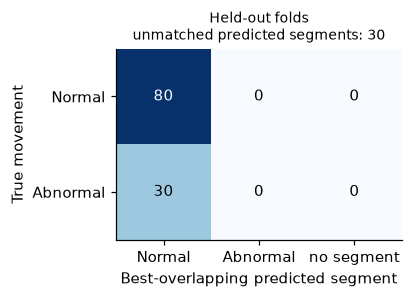

In [19]:
class AlwaysNormal(GapPipeline):
    """Labels every movement Normal."""

    def fit_movements(self, table):
        pass

    def classify(self, table):
        return np.zeros(len(table), dtype=bool), np.zeros(len(table))


result = run_experiment('baseline', 'always_normal', AlwaysNormal, params={'model': 'always_normal'}, few_shot=False)
show(result)

<blockquote><h3 id="5-2"><b>5.2 Window-Current Rule</b></h3></blockquote>

The team's baseline labels a movement Abnormal resistance when its window current exceeds a threshold for its
operation. The threshold is the midpoint of the gap between the two classes in the training movements, or the
midpoint of the class medians if they overlap. The table gives the thresholds of every fold.

🏃 View run window_current_rule at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12/runs/e78eb79eb5f34072a6b859fbe94c1620
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12


,value
IoU-weighted F1,1.0
95% interval,1.000 to 1.000
soft recall,1.0
soft precision,1.0
mean IoU of matches,1.0
wrong label,0
missed,0
unmatched segments,0
block_iou_f1,1.0
no_gap_iou_f1,0.004499


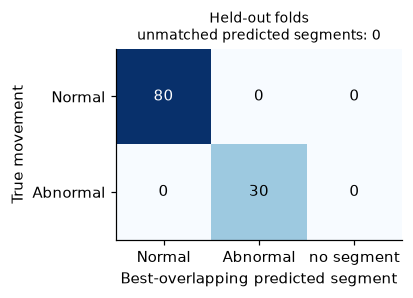

,Close,Open
fold,,
0,248.1,467.7
1,304.8,467.7
2,248.9,466.6
3,248.9,482.7
4,248.9,467.7


In [20]:
class WindowCurrentRule(GapPipeline):
    """The team's baseline: abnormal when the window current exceeds a threshold per operation."""

    def fit_movements(self, table):
        self.thresholds_ = {}
        for operation, g in table.groupby('operation'):
            normal, abnormal = g.loc[g['label'].eq(0), 'window_current'], g.loc[g['label'].eq(1), 'window_current']
            gap = abnormal.min() > normal.max()
            self.thresholds_[operation] = float((normal.max() + abnormal.min()) / 2 if gap else (normal.median() + abnormal.median()) / 2)

    def classify(self, table):
        margin = table['window_current'].to_numpy() - table['operation'].map(self.thresholds_).to_numpy(dtype=float)
        return margin > 0, margin


def rule_tables(result):
    """Thresholds of every fold."""
    return {'fold_thresholds': pd.DataFrame({g: m.thresholds_ for g, m in result['models'].items()}).T.rename_axis('fold')}


result = run_experiment('baseline', 'window_current_rule', WindowCurrentRule,
                        params={'model': 'window_current_rule', 'windows': json.dumps(CONFIG['windows'])}, tables=rule_tables)
show(result)
display(rule_tables(result)['fold_thresholds'].round(1))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Logistic Regression</b></h2>
</div>

The first learned model is a class-weighted logistic regression for each operation on the three middle-stroke
aggregates of Section 2.5, standardised with training constants. Two variants add detail that the Train folds
might reward but the difference between the streams argues against: the 20 travel bins, and the start-phase,
end-phase and back electromotive force features. The runs are recorded in the experiment
`door_logistic_regression`.

<blockquote><h3 id="6-1"><b>6.1 Logistic Classifier</b></h3></blockquote>

Each operation gets its own model, because the two operations draw very different currents. Missing values,
which only very short segments could produce, are filled with the training median.

In [21]:
class LogisticModel(GapPipeline):
    """Class-weighted logistic regression per operation on standardised movement features."""

    def __init__(self, features, c):
        self.features, self.c = list(features), c

    def fit_movements(self, table):
        self.models_ = {operation: make_pipeline(SimpleImputer(strategy='median', keep_empty_features=True), StandardScaler(),
                                                 LogisticRegression(C=self.c, class_weight='balanced', max_iter=5000))
                        .fit(g[self.features], g['label']) for operation, g in table.groupby('operation')}

    def classify(self, table):
        probability = np.full(len(table), np.nan)
        for operation, index in table.groupby('operation').groups.items():
            if operation in self.models_:
                probability[table.index.get_indexer(index)] = self.models_[operation].predict_proba(table.loc[index, self.features])[:, 1]
        return probability >= 0.5, probability


def logistic_params(features):
    return {'model': 'logistic_regression', 'n_features': len(features), 'c': CONFIG['logistic_c'], 'class_weight': 'balanced'}

<blockquote><h3 id="6-2"><b>6.2 Middle-Stroke Features</b></h3></blockquote>

The model on the three middle-stroke aggregates is the candidate from this architecture.

🏃 View run middle_stroke_features at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13/runs/b8708c0b498e419a9ed3f19651e3d36e
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13


,value
IoU-weighted F1,0.990909
95% interval,0.973 to 1.000
soft recall,0.990909
soft precision,0.990909
mean IoU of matches,1.0
wrong label,1
missed,0
unmatched segments,1
block_iou_f1,0.990909
no_gap_iou_f1,0.004509


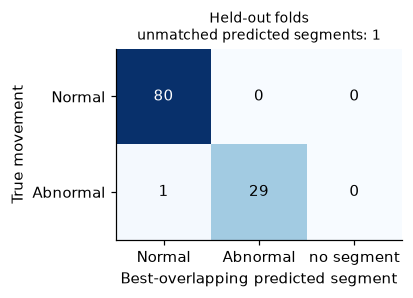

In [22]:
result = run_experiment('logistic_regression', 'middle_stroke_features', lambda: LogisticModel(FEATURES, CONFIG['logistic_c']),
                        params=logistic_params(FEATURES))
show(result)

<blockquote><h3 id="6-3"><b>6.3 Added Detail</b></h3></blockquote>

The first variant adds the 20 travel bins; the second adds the start-phase and end-phase mean and maximum current
and the mean back electromotive force. Both are diagnostics and do not compete.

In [23]:
VARIANTS = {'with_travel_bins': FEATURES + BIN_COLUMNS,
            'with_start_end_phases': FEATURES + ['start_mean_current', 'start_max_current', 'end_mean_current',
                                                 'end_max_current', 'mean_back_emf']}
for name, columns in VARIANTS.items():
    run_experiment('logistic_regression', name, lambda columns=columns: LogisticModel(columns, CONFIG['logistic_c']),
                   params=logistic_params(columns), role='variant')
display(score_table([('logistic_regression', 'middle_stroke_features')] + [('logistic_regression', n) for n in VARIANTS]).round(3))

🏃 View run with_travel_bins at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13/runs/95707361e49942efb09783e533f95086
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13


🏃 View run with_start_end_phases at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13/runs/76186898522e4174b7c009b47f0a74ef
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/13


,IoU-F1,block_iou_f1,no_gap_iou_f1,few_shot_1_iou_f1,few_shot_2_iou_f1,few_shot_3_iou_f1,few_shot_mean_iou_f1
logistic_regression / middle_stroke_features,0.991,0.991,0.005,0.991,0.991,0.989,0.990
logistic_regression / with_travel_bins,0.982,0.991,0.005,0.976,0.985,0.985,0.982
logistic_regression / with_start_end_phases,1.000,1.000,0.005,0.995,0.998,0.996,0.996


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Gradient Boosting</b></h2>
</div>

Gradient-boosted trees can combine thresholds on several features and let the operation change them. LightGBM
is trained on the three middle-stroke aggregates and the operation, with balanced class weights and small
trees: four leaves, at least five movements per leaf, and 100 rounds at a learning rate of 0.05. The run is
recorded in the experiment `door_gradient_boosting`.

<blockquote><h3 id="7-1"><b>7.1 LightGBM Classifier</b></h3></blockquote>

The model on the middle-stroke aggregates and the operation is the candidate from this architecture. The table
after it gives the total gain of each feature, averaged over the folds.

🏃 View run middle_stroke_features at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/14/runs/e6ffebd9a48646afa420a49bf6946ffa
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/14


,value
IoU-weighted F1,0.990909
95% interval,0.973 to 1.000
soft recall,0.990909
soft precision,0.990909
mean IoU of matches,1.0
wrong label,1
missed,0
unmatched segments,1
block_iou_f1,1.0
no_gap_iou_f1,0.004499


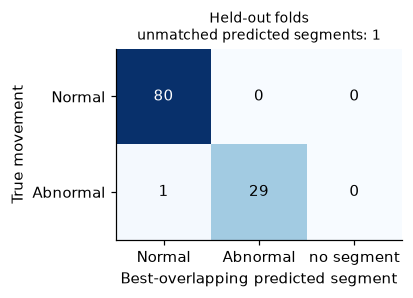

,mean gain
middle_mean_current,960.2
window_current,280.7
is_open,2.8
middle_max_current,0.1


In [24]:
class BoostedTrees(GapPipeline):
    """LightGBM trees on movement features and the operation, with balanced class weights."""

    def __init__(self, features, params):
        self.features, self.params = list(features) + ['is_open'], dict(params)

    def fit_movements(self, table):
        self.model_ = lgb.LGBMClassifier(objective='binary', class_weight='balanced', random_state=SEED, deterministic=True,
                                         force_row_wise=True, verbose=-1, **self.params).fit(table[self.features], table['label'])

    def classify(self, table):
        probability = self.model_.predict_proba(table[self.features])[:, 1]
        return probability >= 0.5, probability


result = run_experiment('gradient_boosting', 'middle_stroke_features', lambda: BoostedTrees(FEATURES, CONFIG['lightgbm']),
                        params={'model': 'lightgbm', 'n_features': len(FEATURES) + 1, **CONFIG['lightgbm']})
show(result)
gain = pd.DataFrame({g: pd.Series(m.model_.booster_.feature_importance('gain'), index=m.features)
                     for g, m in result['models'].items()})
display(gain.mean(axis=1).sort_values(ascending=False).rename('mean gain').to_frame().round(1))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Normal-Only Envelope</b></h2>
</div>

Fault examples are scarce, and the info kit notes that thresholds set from them are hard to validate. This model
therefore learns only what Normal movements look like. For each operation it records the median current of
Normal training movements in every travel bin between 10% and 90% of the stroke, with a robust spread, and
scores a movement by how many spreads above that envelope it runs on average: resistance at any point of the
track shows as extra current at that door position, whatever the speed. The threshold is five robust standard
deviations above the scores of the Normal training movements, fixed in advance rather than tuned, so no
abnormal movement is used at all. A second version addresses the difference between doors that the info kit
describes: it centres the envelope on the stream being scored, so each door is compared with its own typical
movement. Both runs are recorded in the experiment `door_normal_envelope`.

<blockquote><h3 id="8-1"><b>8.1 Envelope Model</b></h3></blockquote>

Travel bins before 10% and after 90% of the stroke, where the start-up peak and braking dominate and the Test
stream differs most from Train, are left out. Spreads are floored at 1 mA per bin and 0.1 standard deviations
for the score, so that a very tight envelope cannot produce extreme values.

🏃 View run position_envelope at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/15/runs/9e398984462a4150b9ad9f50920a42e4
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/15


,value
IoU-weighted F1,0.981818
95% interval,0.955 to 1.000
soft recall,0.981818
soft precision,0.981818
mean IoU of matches,1.0
wrong label,2
missed,0
unmatched segments,2
block_iou_f1,0.981818
no_gap_iou_f1,0.004509


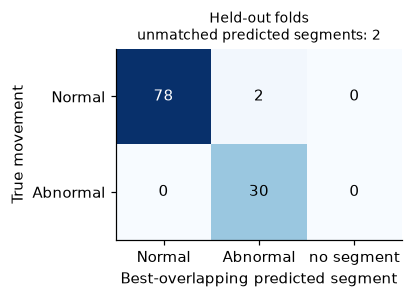

In [25]:
class NormalEnvelope(GapPipeline):
    """Current envelope of Normal movements by door position; flags movements that run above it."""

    def __init__(self, bins, k, min_movements=None):
        self.bins, self.columns, self.k = list(bins), BIN_COLUMNS[bins[0]:bins[1]], k

    def excess(self, table, operation):
        return ((table[self.columns] - self.centre_[operation]) / self.scale_[operation]).mean(axis=1).to_numpy()

    def fit_movements(self, table):
        self.centre_, self.scale_, self.threshold_ = {}, {}, {}
        for operation, g in table[table['label'].eq(0)].groupby('operation'):
            values = g[self.columns]
            self.centre_[operation] = values.median()
            self.scale_[operation] = np.maximum(1.4826 * (values - values.median()).abs().median(), 1.0)
            scores = self.excess(g, operation)
            spread = max(1.4826 * float(np.median(np.abs(scores - np.median(scores)))), 0.1)
            self.threshold_[operation] = float(np.median(scores) + self.k * spread)

    def classify(self, table):
        score = np.full(len(table), np.nan)
        for operation, index in table.groupby('operation').groups.items():
            if operation in self.threshold_:
                score[table.index.get_indexer(index)] = self.excess(table.loc[index], operation) - self.threshold_[operation]
        return score > 0, score


def envelope_tables(result):
    """Thresholds of every fold, in robust standard deviations."""
    return {'fold_thresholds': pd.DataFrame({g: m.threshold_ for g, m in result['models'].items()}).T.rename_axis('fold')}


result = run_experiment('normal_envelope', 'position_envelope', lambda: NormalEnvelope(**CONFIG['envelope']),
                        params={'model': 'normal_envelope', 'bins': json.dumps(CONFIG['envelope']['bins']), 'k': CONFIG['envelope']['k']},
                        tables=envelope_tables)
show(result)

<blockquote><h3 id="8-2"><b>8.2 Stream-Referenced Envelope</b></h3></blockquote>

The second version keeps the spreads learned from Normal training movements but takes the centre of the envelope
from the stream being scored: the median current of all its movements of the same operation in every travel
bin. Most movements of a stream are Normal, so the median follows the door's own normal level, and a shift that
affects the whole stream no longer reads as resistance. The threshold is set the same way, from the Normal
training movements scored against the median of their own training stream. A stream with fewer than five
movements of an operation falls back to the Train envelope.

🏃 View run stream_referenced_envelope at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/15/runs/94defc965d484f169207d9f3af477a4c
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/15


,value
IoU-weighted F1,0.981818
95% interval,0.955 to 1.000
soft recall,0.981818
soft precision,0.981818
mean IoU of matches,1.0
wrong label,2
missed,0
unmatched segments,2
block_iou_f1,0.981818
no_gap_iou_f1,0.004509


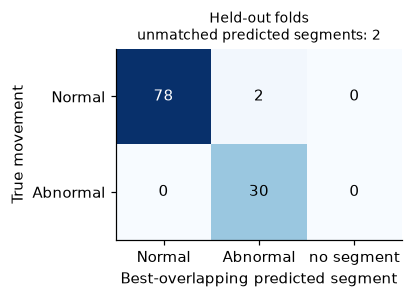

In [26]:
class StreamReferencedEnvelope(NormalEnvelope):
    """The Normal envelope re-centred on the stream being scored."""

    def __init__(self, bins, k, min_movements):
        super().__init__(bins, k)
        self.min_movements = min_movements

    def fit_movements(self, table):
        super().fit_movements(table)
        for operation, g in table.groupby('operation'):
            normal = g[g['label'].eq(0)]
            scores = ((normal[self.columns] - g[self.columns].median()) / self.scale_[operation]).mean(axis=1).to_numpy()
            spread = max(1.4826 * float(np.median(np.abs(scores - np.median(scores)))), 0.1)
            self.threshold_[operation] = float(np.median(scores) + self.k * spread)

    def classify(self, table):
        score = np.full(len(table), np.nan)
        for operation, index in table.groupby('operation').groups.items():
            if operation in self.threshold_:
                rows = table.loc[index]
                centre = rows[self.columns].median() if len(rows) >= self.min_movements else self.centre_[operation]
                excess = ((rows[self.columns] - centre) / self.scale_[operation]).mean(axis=1).to_numpy()
                score[table.index.get_indexer(index)] = excess - self.threshold_[operation]
        return score > 0, score


result = run_experiment('normal_envelope', 'stream_referenced_envelope', lambda: StreamReferencedEnvelope(**CONFIG['envelope']),
                        params={'model': 'stream_referenced_envelope', 'bins': json.dumps(CONFIG['envelope']['bins']),
                                'k': CONFIG['envelope']['k'], 'min_movements': CONFIG['envelope']['min_movements']},
                        tables=envelope_tables)
show(result)

<blockquote><h3 id="8-3"><b>8.3 Envelope Scores</b></h3></blockquote>

The score of every held-out Train movement under the stream-referenced envelope, relative to its threshold,
shows how far the two classes lie from the decision boundary for each operation.

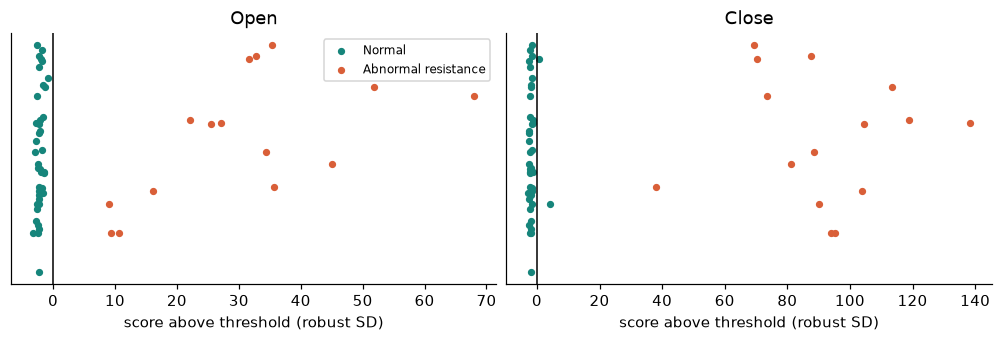

In [27]:
envelope = RESULTS[('normal_envelope', 'stream_referenced_envelope')]
scored = pd.concat([p.assign(status=t['status'].to_numpy(dtype=object)) for t, p in envelope['parts']], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, operation in zip(axes, ['Open', 'Close']):
    for status in [NORMAL, ABNORMAL]:
        values = scored.loc[scored['operation'].eq(operation) & scored['status'].eq(status), 'score']
        ax.scatter(values, np.random.default_rng(SEED).uniform(-0.3, 0.3, len(values)), s=14, color=COLORS[status], label=status)
    ax.axvline(0, color='black', linewidth=1)
    ax.set(title=operation, xlabel='score above threshold (robust SD)', yticks=[])
axes[0].legend(fontsize=8)
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Random Convolutional Kernels</b></h2>
</div>

ROCKET (Dempster et al., 2020) is a strong and fast method for time-series classification. It convolves each
series with thousands of random kernels of random length, weights, bias and dilation, keeps two numbers per
kernel, the share of positive outputs and the maximum, and trains only a linear classifier on them. Here 1,000
kernels run over the 100-point profiles of current, voltage, back electromotive force and position, each kernel
on one randomly chosen signal, and a ridge classifier with balanced class weights and a regularisation strength
chosen by leave-one-out cross-validation learns from the 2,000 features and the operation. The run is recorded
in the experiment `door_rocket`.

<blockquote><h3 id="9-1"><b>9.1 ROCKET Classifier</b></h3></blockquote>

The kernels are drawn once from the seed, so every fold uses the same transform. The profiles are scaled with
training constants per signal rather than per movement, which keeps the absolute current level that
distinguishes resistance.

🏃 View run rocket_profiles at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/16/runs/b8f0c684df634dffa511f88ace33b8c4
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/16


,value
IoU-weighted F1,1.0
95% interval,1.000 to 1.000
soft recall,1.0
soft precision,1.0
mean IoU of matches,1.0
wrong label,0
missed,0
unmatched segments,0
block_iou_f1,1.0
no_gap_iou_f1,0.004519


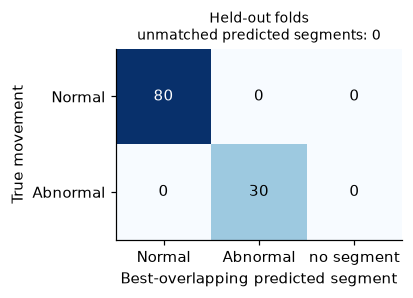

In [28]:
class RocketModel(GapPipeline):
    """Random convolutional kernels over the movement profiles, followed by a ridge classifier."""

    def __init__(self, n_kernels, lengths, alphas):
        self.n_kernels, self.alphas = n_kernels, list(alphas)
        rng = np.random.default_rng(SEED)
        self.kernels = []
        for _ in range(n_kernels):
            length = int(rng.choice(lengths))
            weights = rng.normal(size=length)
            dilation = int(2 ** rng.uniform(0, np.log2((POINTS - 1) / (length - 1))))
            padding = (length - 1) * dilation // 2 if rng.integers(2) else 0
            self.kernels.append((int(rng.integers(len(SIGNALS))), weights - weights.mean(), float(rng.uniform(-1, 1)), dilation, padding))

    def signals(self, table):
        return table[PROFILE_COLUMNS].to_numpy(dtype=float).reshape(len(table), len(SIGNALS), POINTS)

    def transform(self, table):
        x = (self.signals(table) - self.mean_[None, :, None]) / self.std_[None, :, None]
        features = np.empty((len(table), 2 * self.n_kernels))
        for k, (signal, weights, bias, dilation, padding) in enumerate(self.kernels):
            series = np.pad(x[:, signal, :], ((0, 0), (padding, padding)))
            width = series.shape[1] - (len(weights) - 1) * dilation
            output = bias + sum(w * series[:, i * dilation:i * dilation + width] for i, w in enumerate(weights))
            features[:, 2 * k], features[:, 2 * k + 1] = (output > 0).mean(axis=1), output.max(axis=1)
        return np.column_stack([features, table['is_open'].to_numpy()])

    def fit_movements(self, table):
        values = self.signals(table)
        self.mean_, self.std_ = values.mean(axis=(0, 2)), values.std(axis=(0, 2)) + 1e-9
        self.model_ = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=self.alphas, class_weight='balanced'))
        self.model_.fit(self.transform(table), table['label'])

    def classify(self, table):
        score = self.model_.decision_function(self.transform(table))
        return score > 0, score


result = run_experiment('rocket', 'rocket_profiles', lambda: RocketModel(**CONFIG['rocket']),
                        params={'model': 'rocket', 'n_kernels': CONFIG['rocket']['n_kernels'],
                                'lengths': json.dumps(CONFIG['rocket']['lengths']), 'alphas': json.dumps(CONFIG['rocket']['alphas'])})
show(result)

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Profile Convolutional Network</b></h2>
</div>

A convolutional network learns its own filters from the profiles instead of drawing them at random. This one is
small, to suit about 88 training movements per fold: two convolutional layers of 16 and 32 filters of width 5
with batch normalisation, global average pooling, the operation as an extra input, a dense layer of 16 units
and a sigmoid output. It is trained with class-weighted binary cross-entropy and Adam at a learning rate of 0.001
in batches of 16, and stops after 30 epochs without improvement on a stratified 20% of the training movements,
keeping the best weights, or after 400 epochs. The run is recorded in the experiment `door_profile_cnn`.

<blockquote><h3 id="10-1"><b>10.1 Network and Classifier</b></h3></blockquote>

The profiles are scaled with training constants per signal, as for ROCKET. For packaging, the classifier stores
the network's weights and rebuilds it when loaded.

In [29]:
def build_profile_cnn(settings):
    """Two convolutional layers over the profiles, joined with the operation before the output."""
    keras.utils.set_random_seed(SEED)
    profile_in = layers.Input((POINTS, len(SIGNALS)), name='profile')
    operation_in = layers.Input((1,), name='is_open')
    x = profile_in
    for filters in settings['filters']:
        x = layers.BatchNormalization()(layers.Conv1D(filters, settings['kernel'], padding='same', activation='relu')(x))
    x = layers.Concatenate()([layers.GlobalAveragePooling1D()(x), operation_in])
    output = layers.Dense(1, activation='sigmoid')(layers.Dense(settings['dense'], activation='relu')(x))
    return keras.Model([profile_in, operation_in], output, name='profile_cnn')


class ProfileCNN(GapPipeline):
    """A small convolutional network on the scaled movement profiles and the operation."""

    def __init__(self, settings):
        self.settings = dict(settings)

    def inputs(self, table):
        values = table[PROFILE_COLUMNS].to_numpy(dtype=np.float32).reshape(len(table), len(SIGNALS), POINTS).transpose(0, 2, 1)
        return [(values - self.mean_) / self.std_, table[['is_open']].to_numpy(dtype=np.float32)]

    def fit_movements(self, table):
        s, labels = self.settings, table['label'].to_numpy()
        values = table[PROFILE_COLUMNS].to_numpy(dtype=np.float32).reshape(len(table), len(SIGNALS), POINTS).transpose(0, 2, 1)
        self.mean_, self.std_ = values.mean(axis=(0, 1)), values.std(axis=(0, 1)) + 1e-6
        train_idx, valid_idx = train_test_split(np.arange(len(table)), test_size=s['validation_share'], random_state=SEED, stratify=labels)
        x, y = self.inputs(table), labels.astype('float32')
        self.network_ = build_profile_cnn(s)
        self.network_.compile(optimizer=keras.optimizers.Adam(s['learning_rate']), loss='binary_crossentropy')
        history = self.network_.fit([v[train_idx] for v in x], y[train_idx], validation_data=([v[valid_idx] for v in x], y[valid_idx]),
                                    batch_size=s['batch_size'], epochs=s['max_epochs'], verbose=0,
                                    class_weight={c: len(labels) / (2 * max(int((labels == c).sum()), 1)) for c in (0, 1)},
                                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True)])
        self.history_ = pd.DataFrame(history.history).rename_axis('epoch')

    def classify(self, table):
        probability = self.network_.predict(self.inputs(table), verbose=0).ravel()
        return probability >= 0.5, probability

    def __getstate__(self):
        state = {k: v for k, v in self.__dict__.items() if k != 'network_'}
        if 'network_' in self.__dict__:
            state['weights_'] = self.network_.get_weights()
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        if 'weights_' in state:
            self.network_ = build_profile_cnn(self.settings)
            self.network_.set_weights(state['weights_'])

<blockquote><h3 id="10-2"><b>10.2 Cross-Validated Training</b></h3></blockquote>

A fresh network is trained for every fold, block and few-example draw. The network is the candidate from this
architecture; the table after it gives the epochs trained in each fold.

🏃 View run profile_cnn at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/17/runs/d547d0ff1dad461ea428ee15363a07a6
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/17


,value
IoU-weighted F1,1.0
95% interval,1.000 to 1.000
soft recall,1.0
soft precision,1.0
mean IoU of matches,1.0
wrong label,0
missed,0
unmatched segments,0
block_iou_f1,0.872727
no_gap_iou_f1,0.004509


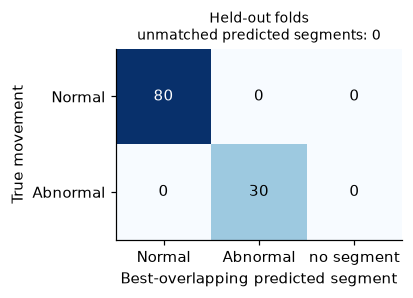

,epochs run,best epoch
fold,,
0,180,150
1,400,400
2,50,20
3,400,400
4,282,252


In [30]:
result = run_experiment('profile_cnn', 'profile_cnn', lambda: ProfileCNN(CONFIG['profile_cnn']),
                        params={'model': 'profile_cnn', **{k: json.dumps(v) if isinstance(v, list) else v for k, v in CONFIG['profile_cnn'].items()}})
show(result)
display(pd.DataFrame([{'fold': g, 'epochs run': len(m.history_), 'best epoch': int(m.history_['val_loss'].idxmin()) + 1}
                      for g, m in result['models'].items()]).set_index('fold'))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Stream Tagger</b></h2>
</div>

Every model so far finds movements from the logging pauses, which the exploratory analysis flagged as
unverified for a continuous live log. The stream tagger finds them from the signals instead. A temporal
convolutional network reads the 15 informative columns of the stream sample by sample, without timestamps, and
predicts for every sample whether it starts a movement and whether it belongs to a movement with abnormal
resistance. A movement starts at every sample whose start probability peaks above 0.5 at least one second after
the previous start, and each movement takes the label of its mean abnormal probability. The run is recorded in
the experiment `door_stream_tagger`.

<blockquote><h3 id="11-1"><b>11.1 Tagger Network</b></h3></blockquote>

The network lifts the scaled inputs to 32 channels and stacks five residual convolutions of width 3 with
dilations 1, 2, 4, 8 and 16, so each output sees about 60 samples, or 1.2 seconds, on either side; two
one-by-one convolutions give the start and abnormal probabilities. It is trained on windows of 512 samples,
taken every 128 samples, from the training stream with its pauses removed, with binary cross-entropy that
weights the rare start samples 50 times. Training stops after 15 epochs without improvement on the last 20% of
the training movements, keeping the best weights, or after 150 epochs.

In [31]:
TAGGER_COLUMNS = [c for c in RAW_COLUMNS if c not in ('Datetime', 'Door Locked')]


def build_stream_tagger(n_inputs, settings):
    """Dilated residual convolutions over the stream, with a start head and an abnormal head."""
    keras.utils.set_random_seed(SEED)
    inputs = layers.Input((None, n_inputs), name='samples')
    x = layers.Conv1D(settings['filters'], 1, activation='relu')(inputs)
    for dilation in settings['dilations']:
        x = layers.Add()([x, layers.Conv1D(settings['filters'], settings['kernel'], dilation_rate=dilation, padding='same',
                                           activation='relu')(x)])
    start = layers.Conv1D(1, 1, activation='sigmoid', name='start')(x)
    abnormal = layers.Conv1D(1, 1, activation='sigmoid', name='abnormal')(x)
    return keras.Model(inputs, [start, abnormal], name='stream_tagger')


def weighted_bce(weight):
    """Binary cross-entropy with the positive class weighted `weight` times."""
    def loss(y_true, y_pred):
        y_pred = keras.ops.clip(y_pred, 1e-7, 1 - 1e-7)
        return keras.ops.mean(-(weight * y_true * keras.ops.log(y_pred) + (1 - y_true) * keras.ops.log(1 - y_pred)))
    return loss


def pick_starts(probability, min_distance):
    """Sample 0 and every local peak above 0.5 at least `min_distance` samples after the previous start."""
    starts = [0]
    for i in np.flatnonzero(probability >= 0.5):
        neighbourhood = probability[max(0, i - min_distance):i + min_distance + 1]
        if probability[i] == neighbourhood.max() and i - starts[-1] >= min_distance:
            starts.append(int(i))
    return starts


def windows(arrays, length, stride):
    """Overlapping windows of equal length from aligned arrays; the last window ends at the last sample."""
    n = len(arrays[0])
    starts = list(range(0, n - length + 1, stride))
    if starts[-1] + length < n:
        starts.append(n - length)
    return [np.stack([a[s:s + length] for s in starts]) for a in arrays]


class StreamTagger:
    """Finds and labels movements from the signals alone, without timestamps."""

    input_columns = RAW_COLUMNS
    row_key = ['Datetime']

    def __init__(self, settings):
        self.settings = dict(settings)

    def scaled(self, stream):
        return (stream[TAGGER_COLUMNS].to_numpy(dtype=np.float32) - self.mean_) / self.std_

    def fit(self, stream, truth):
        s, stream = self.settings, stream.reset_index(drop=True)
        values = stream[TAGGER_COLUMNS].to_numpy(dtype=np.float32)
        self.mean_, self.std_ = values.mean(axis=0), values.std(axis=0) + 1e-6
        times = stream['time'].to_numpy()
        start = np.isin(times, truth['start'].to_numpy()).astype('float32')[:, None]
        abnormal = np.zeros((len(stream), 1), dtype='float32')
        for first, last in truth.loc[truth['status'].to_numpy(dtype=object) == ABNORMAL, ['start', 'end']].itertuples(index=False):
            abnormal[(times >= first) & (times <= last)] = 1
        cut = int(np.flatnonzero(start[:, 0])[int(len(truth) * (1 - s['validation_share']))])
        x = self.scaled(stream)
        train = windows([x[:cut], start[:cut], abnormal[:cut]], s['window'], s['stride'])
        valid = windows([x[cut:], start[cut:], abnormal[cut:]], s['window'], s['window'])
        self.network_ = build_stream_tagger(len(TAGGER_COLUMNS), s)
        self.network_.compile(optimizer=keras.optimizers.Adam(s['learning_rate']),
                              loss=[weighted_bce(s['start_weight']), weighted_bce(1.0)])
        history = self.network_.fit(train[0], train[1:], validation_data=(valid[0], valid[1:]), batch_size=s['batch_size'],
                                    epochs=s['max_epochs'], verbose=0,
                                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True)])
        self.history_ = pd.DataFrame(history.history).rename_axis('epoch')
        return self

    def probabilities(self, stream):
        start, abnormal = self.network_.predict(self.scaled(stream)[None], verbose=0)
        return start[0, :, 0], abnormal[0, :, 0]

    def predict(self, stream):
        stream = stream.reset_index(drop=True)
        start, abnormal = self.probabilities(stream)
        bounds = pick_starts(start, self.settings['min_distance']) + [len(stream)]
        rows = [{'start': stream['time'].iloc[a], 'end': stream['time'].iloc[b - 1],
                 'operation': 'Open' if stream['Open command'].iloc[a:b].max() == 1 else 'Close',
                 'prediction': ABNORMAL if abnormal[a:b].mean() >= 0.5 else NORMAL, 'score': float(abnormal[a:b].mean())}
                for a, b in zip(bounds[:-1], bounds[1:])]
        return pd.DataFrame(rows)

    def __getstate__(self):
        state = {k: v for k, v in self.__dict__.items() if k != 'network_'}
        if 'network_' in self.__dict__:
            state['weights_'] = self.network_.get_weights()
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        if 'weights_' in state:
            self.network_ = build_stream_tagger(len(TAGGER_COLUMNS), self.settings)
            self.network_.set_weights(state['weights_'])

<blockquote><h3 id="11-2"><b>11.2 Cross-Validated Training</b></h3></blockquote>

The tagger is evaluated like every other model, but its segments come from its own start predictions, so their
bounds can differ from the true ones. The check with few abnormal examples is not run, because the tagger also
has to learn segmentation from the training stream.

🏃 View run tcn_tagger at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/18/runs/f7e88fe35aab4837a10c3eb884dd0a05
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/18


,value
IoU-weighted F1,0.977281
95% interval,0.950 to 1.000
soft recall,0.972839
soft precision,0.981764
mean IoU of matches,0.990855
wrong label,2
missed,0
unmatched segments,1
block_iou_f1,0.945455
no_gap_iou_f1,0.981622


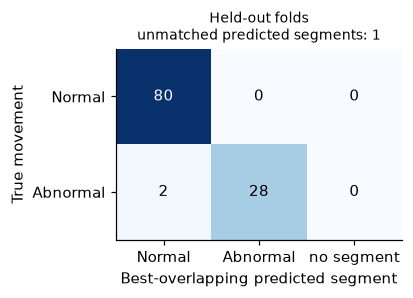

In [32]:
result = run_experiment('stream_tagger', 'tcn_tagger', lambda: StreamTagger(CONFIG['stream_tagger']),
                        params={'model': 'stream_tagger', 'inputs': len(TAGGER_COLUMNS),
                                **{k: json.dumps(v) if isinstance(v, list) else v for k, v in CONFIG['stream_tagger'].items()}},
                        few_shot=False)
show(result)

<blockquote><h3 id="11-3"><b>11.3 Tagger Output on a Held-Out Stretch</b></h3></blockquote>

The plot shows the tagger's two probabilities over the first eight movements of the first held-out fold, with
the pauses removed, together with the true movement starts and the true abnormal movements.

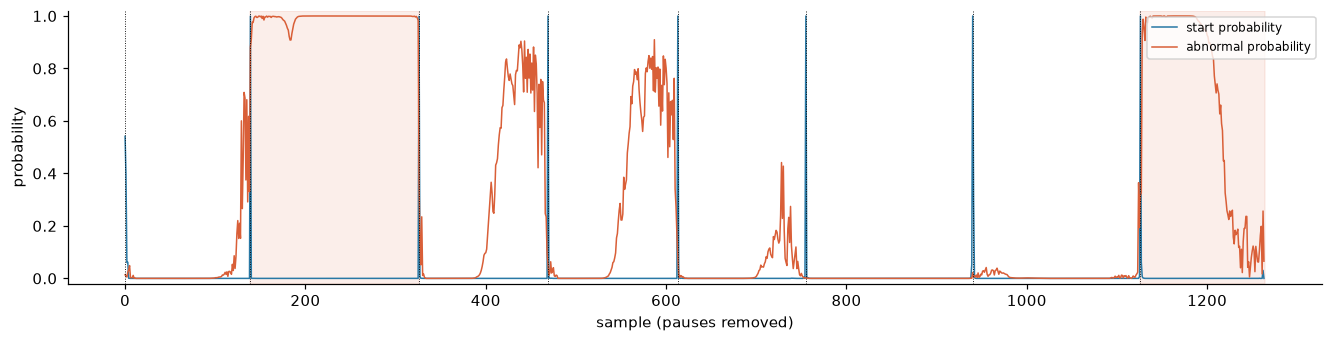

In [33]:
tagger, first = RESULTS[('stream_tagger', 'tcn_tagger')]['models'][SPLITS['fold'][0]], SPLITS['fold'][0]
ids = TRAIN.loc[TRAIN['fold'].eq(first), 'movement_id'].head(8)
stretch, stretch_truth = stream_of(ids), truth_of(ids)
start_p, abnormal_p = tagger.probabilities(stretch)
true_start = np.flatnonzero(np.isin(stretch['time'].to_numpy(), stretch_truth['start'].to_numpy()))
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(start_p, color='#2878a5', linewidth=1, label='start probability')
ax.plot(abnormal_p, color=COLORS[ABNORMAL], linewidth=1, label='abnormal probability')
for i, (first_row, status) in enumerate(zip(true_start, stretch_truth['status'].to_numpy(dtype=object))):
    last_row = true_start[i + 1] if i + 1 < len(true_start) else len(stretch)
    if status == ABNORMAL:
        ax.axvspan(first_row, last_row, color=COLORS[ABNORMAL], alpha=0.1)
    ax.axvline(first_row, color='black', linewidth=0.6, linestyle=':')
ax.set(xlabel='sample (pauses removed)', ylabel='probability', ylim=(-0.02, 1.02))
ax.legend(loc='upper right', fontsize=8)
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-12" style="color: black;"><b>Section 12: Model Comparison</b></h2>
</div>

This section puts all architectures side by side, using the runs as recorded in MLflow, and selects the model to
carry forward.

<blockquote><h3 id="12-1"><b>12.1 Results Across Experiments</b></h3></blockquote>

The runs of this execution are read back from the tracking server by their `notebook_run` tag. The table lists
every run in the order it was built, with its IoU-weighted F1 on the held-out folds and the bootstrap interval,
and the three checks: the score on the time blocks, on the held-out streams without gaps, and with only one,
two or three abnormal training movements per operation, followed by the mean IoU of the matched segments.

In [34]:
EXPERIMENTS = [f'door_{arch}' for arch in dict.fromkeys(arch for arch, _ in RESULTS)]
LABELS = [f'{arch} / {name}' for arch, name in RESULTS]
experiment_names = {experiment_id(name): name.removeprefix('door_') for name in EXPERIMENTS}
runs = mlflow.search_runs(experiment_names=EXPERIMENTS, filter_string=f"tags.notebook_run = '{NOTEBOOK_RUN}'")
runs.index = runs['experiment_id'].map(experiment_names) + ' / ' + runs['tags.mlflow.runName']
runs = runs[runs['tags.role'].ne('final')].reindex(LABELS)
assert runs['run_id'].notna().all(), 'Some runs of this execution were not found on the tracking server.'
COMPARISON = pd.DataFrame({'role': runs['tags.role'], 'IoU-F1': runs['metrics.iou_f1'],
                           'CI low': runs['metrics.iou_f1_ci_low'], 'CI high': runs['metrics.iou_f1_ci_high'],
                           'time blocks': runs['metrics.block_iou_f1'], 'without gaps': runs['metrics.no_gap_iou_f1'],
                           **{f'{m} abnormal': runs[f'metrics.few_shot_{m}_iou_f1'] for m in CONFIG['few_shot']['abnormal_per_operation']},
                           'few-shot mean': runs['metrics.few_shot_mean_iou_f1'], 'mean IoU': runs['metrics.mean_matched_iou']})
display(COMPARISON.round(3))

,role,IoU-F1,CI low,CI high,time blocks,without gaps,1 abnormal,2 abnormal,3 abnormal,few-shot mean,mean IoU
baseline / always_normal,candidate,0.727,0.727,0.727,0.727,0.005,NaN,NaN,NaN,NaN,1.000
baseline / window_current_rule,candidate,1.000,1.000,1.000,1.000,0.004,0.973,0.984,0.993,0.983,1.000
logistic_regression / middle_stroke_features,candidate,0.991,0.973,1.000,0.991,0.005,0.991,0.991,0.989,0.990,1.000
logistic_regression / with_travel_bins,variant,0.982,0.955,1.000,0.991,0.005,0.976,0.985,0.985,0.982,1.000
logistic_regression / with_start_end_phases,variant,1.000,1.000,1.000,1.000,0.005,0.995,0.998,0.996,0.996,1.000
gradient_boosting / middle_stroke_features,candidate,0.991,0.973,1.000,1.000,0.004,0.976,0.976,0.987,0.980,1.000
normal_envelope / position_envelope,candidate,0.982,0.955,1.000,0.982,0.005,0.982,0.982,0.982,0.982,1.000
normal_envelope / stream_referenced_envelope,candidate,0.982,0.955,1.000,0.982,0.005,0.982,0.982,0.982,0.982,1.000
rocket / rocket_profiles,candidate,1.000,1.000,1.000,1.000,0.005,0.956,0.973,0.987,0.972,1.000
profile_cnn / profile_cnn,candidate,1.000,1.000,1.000,0.873,0.005,0.985,0.955,0.985,0.975,1.000


<blockquote><h3 id="12-2"><b>12.2 Comparison Plots</b></h3></blockquote>

The first plot shows the IoU-weighted F1 of every run on the held-out folds with its bootstrap interval;
candidates are coloured and diagnostic variants grey, and the dashed line is the score of labelling every
movement Normal. The second plot sets each candidate's main score against its three checks.

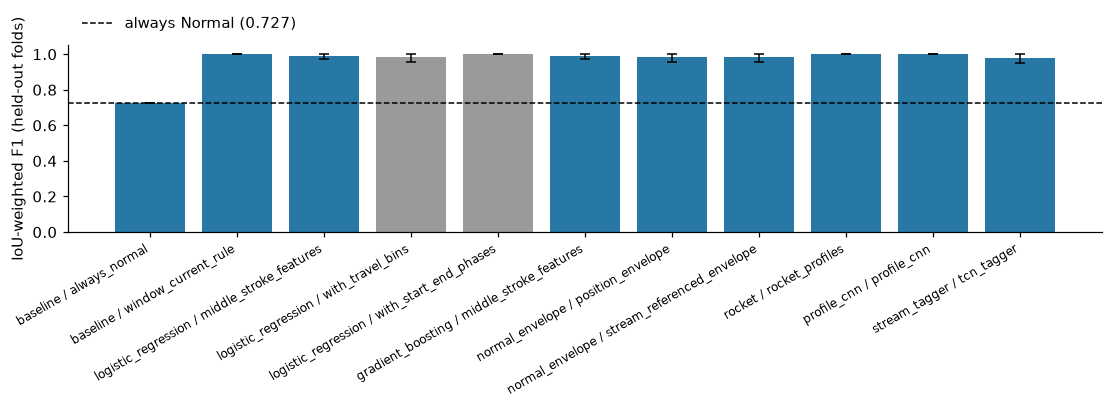

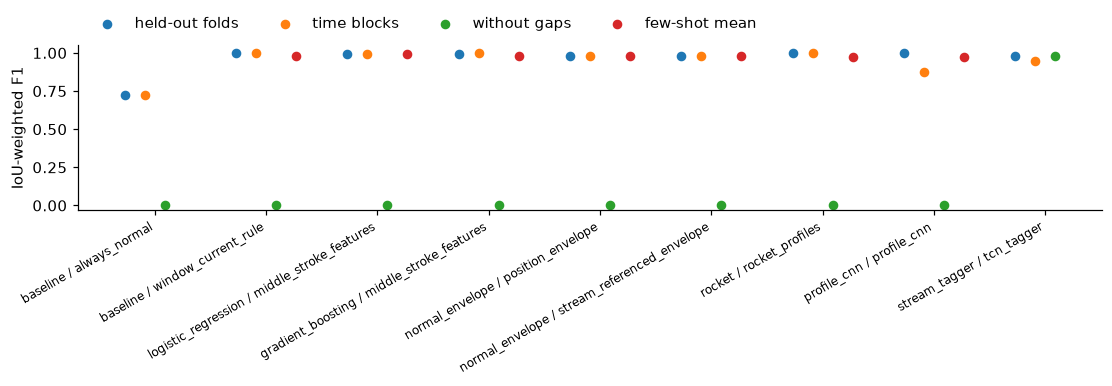

In [35]:
comparison_figure(COMPARISON)
plt.show()
candidates = COMPARISON[COMPARISON['role'].eq('candidate')]
checks = {'held-out folds': 'IoU-F1', 'time blocks': 'time blocks', 'without gaps': 'without gaps', 'few-shot mean': 'few-shot mean'}
fig, ax = plt.subplots(figsize=(10, 3.4))
for offset, (label, column) in zip(np.linspace(-0.27, 0.27, len(checks)), checks.items()):
    ax.scatter(np.arange(len(candidates)) + offset, candidates[column], s=28, label=label)
ax.set(xticks=range(len(candidates)), ylim=(-0.03, 1.05), ylabel='IoU-weighted F1')
ax.set_xticklabels(candidates.index, rotation=30, ha='right', fontsize=8)
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=4, frameon=False)
plt.show()

<blockquote><h3 id="12-3"><b>12.3 Model Selection</b></h3></blockquote>

The selected model is the candidate with the highest IoU-weighted F1 on the held-out folds. Candidates that tie
are separated by their mean score with one to three abnormal training movements per operation, because scarce
fault examples are the first problem the info kit names; any remaining tie goes to the simplest, following the
order in which the architectures were built. The evidence has limits. With 30 abnormal movements, one wrong label
moves the score by about 0.01. The folds and blocks all come from one recording, so they cannot show how a model
transfers to another door or train. And the check without gaps re-times Train data rather than using a real
continuous log.

In [36]:
top = candidates[np.isclose(candidates['IoU-F1'], candidates['IoU-F1'].max())]
robustness = top['few-shot mean'].fillna(-np.inf)
best = top.index[np.isclose(robustness, robustness.max())].tolist()
SELECTED = list(RESULTS)[LABELS.index(best[0])]
client.set_tag(RESULTS[SELECTED]['run_id'], 'selected', 'true')
display(candidates[['IoU-F1', 'CI low', 'CI high', 'few-shot mean']].assign(selected=candidates.index == best[0]).round(3))
print('Selected:', best[0], '| candidates with the same main score:', ', '.join(i for i in top.index if i != best[0]) or 'none')

,IoU-F1,CI low,CI high,few-shot mean,selected
baseline / always_normal,0.727,0.727,0.727,NaN,False
baseline / window_current_rule,1.000,1.000,1.000,0.983,True
logistic_regression / middle_stroke_features,0.991,0.973,1.000,0.990,False
gradient_boosting / middle_stroke_features,0.991,0.973,1.000,0.980,False
normal_envelope / position_envelope,0.982,0.955,1.000,0.982,False
normal_envelope / stream_referenced_envelope,0.982,0.955,1.000,0.982,False
rocket / rocket_profiles,1.000,1.000,1.000,0.972,False
profile_cnn / profile_cnn,1.000,1.000,1.000,0.975,False
stream_tagger / tcn_tagger,0.977,0.950,1.000,NaN,False


Selected: baseline / window_current_rule | candidates with the same main score: rocket / rocket_profiles, profile_cnn / profile_cnn


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-13" style="color: black;"><b>Section 13: Final Model</b></h2>
</div>

This section refits the selected configuration on the whole Train stream, packages it as an MLflow model that
takes a raw stream, registers it, and processes the Test stream.

<blockquote><h3 id="13-1"><b>13.1 Refit on the Train Stream</b></h3></blockquote>

The selected configuration is fitted on the whole Train stream and its 110 labelled movements in a run named
`final_refit`, inside the experiment of its architecture and linked to the evaluation run it came from. No score
is reported for the refit, because it would be measured on the movements it was fitted on.

In [37]:
ARCH, NAME = SELECTED
chosen = RESULTS[SELECTED]
TRAIN_STREAM = STREAMS['Train'][RAW_COLUMNS + ['time']]
FINAL_MODEL = chosen['make_model']()
start = time.perf_counter()
FINAL_MODEL.fit(TRAIN_STREAM, truth_of(TRAIN['movement_id']))
fit_seconds = time.perf_counter() - start
with mlflow.start_run(experiment_id=experiment_id(f'door_{ARCH}'), run_name='final_refit',
                      tags={'notebook_run': NOTEBOOK_RUN, **GIT, 'data_version': DATA_VERSION, 'role': 'final',
                            'evaluation_run_id': chosen['run_id']}) as final_run:
    mlflow.log_params({**chosen['params'], 'training_movements': len(TRAIN), 'seed': SEED})
    mlflow.log_metric('fit_time_s', fit_seconds)
FINAL_RUN_ID = final_run.info.run_id
display(pd.Series({'experiment': f'door_{ARCH}', 'configuration': NAME, **chosen['params']}, name='value').to_frame())

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12/runs/d5c0e1d972b94c47b30e32419ef0f6e1
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12


,value
experiment,door_baseline
configuration,window_current_rule
model,window_current_rule
windows,"{""Open"": [20, 40], ""Close"": [35, 65]}"


<blockquote><h3 id="13-2"><b>13.2 Model Package</b></h3></blockquote>

The fitted model is wrapped as an MLflow Python model whose input is a raw door stream: the 17 columns of the
CSV files, one row per sample. The wrapper rejects missing columns, repeated or unreadable timestamps, rows out of
time order and infinite values, then finds and labels the movements and returns one row per predicted segment
with its native-format bounds, its label and the model's score. The example below is the start of the Train
stream.

In [38]:
class DoorPackage(mlflow.pyfunc.PythonModel):
    """Checks a raw door stream, then finds and labels every movement in it."""

    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input: pd.DataFrame, params=None) -> pd.DataFrame:
        frame = pd.DataFrame(model_input)
        missing = [c for c in self.model.input_columns if c not in frame.columns]
        if missing:
            raise ValueError(f'Missing required columns: {missing}')
        if frame['Datetime'].duplicated().any():
            raise ValueError('Timestamps must be unique.')
        if np.isinf(frame[self.model.input_columns].drop(columns='Datetime').to_numpy(dtype=float)).any():
            raise ValueError('Values must be finite.')
        try:
            times = parse_time(frame['Datetime'].astype(str))
        except (ValueError, KeyError, TypeError) as error:
            raise ValueError('Datetime must use the native Y-M-D-h-m-s-ms format.') from error
        if not times.is_monotonic_increasing:
            raise ValueError('Rows must be in time order.')
        predicted = self.model.predict(frame[self.model.input_columns].assign(time=times.to_numpy()))
        return pd.DataFrame({'start_time': format_time(predicted['start']).to_numpy(), 'end_time': format_time(predicted['end']).to_numpy(),
                             'prediction': predicted['prediction'].to_numpy(), 'score': predicted['score'].to_numpy()})


PACKAGE = DoorPackage(FINAL_MODEL)
EXAMPLE = RAW['Train'].head(400)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Hint: Inferred schema contains integer')  # the stream's signals are integers
    SIGNATURE = infer_signature(EXAMPLE, PACKAGE.predict(None, EXAMPLE))
display(PACKAGE.predict(None, EXAMPLE))

,start_time,end_time,prediction,score
0,2023-7-5-0-0-0-0,2023-7-5-0-0-3-700,Normal,-84.013636
1,2023-7-5-0-0-23-999,2023-7-5-0-0-26-839,Normal,-121.443182
2,2023-7-5-0-0-51-266,2023-7-5-0-0-52-666,Abnormal resistance,1443.769949


<blockquote><h3 id="13-3"><b>13.3 Registration</b></h3></blockquote>

The package is logged to the `final_refit` run with its signature, an input example and pinned requirements,
and registered as a new version of `door_resistance_classifier` with a short description. The new version
receives the `champion` alias. The model is serialised with cloudpickle because it is defined in this notebook.

In [39]:
PINS = [f'{n}=={importlib.metadata.version(n)}' for n in
        ['mlflow', 'numpy', 'pandas', 'scikit-learn', 'lightgbm', 'tensorflow', 'keras', 'cloudpickle']]
DESCRIPTION = (f"Finds every door movement in a raw door-controller stream and labels it Normal or Abnormal resistance. "
               f"Configuration {ARCH} / {NAME}, refitted on the 110 Train movements; IoU-weighted F1 "
               f"{chosen['summary']['iou_f1']:.3f} on the five held-out folds.")
pyfunc_logger = logging.getLogger('mlflow.pyfunc')
previous_level = pyfunc_logger.level
pyfunc_logger.setLevel(logging.ERROR)  # silences the notice about pickled models, which are produced here
try:
    with mlflow.start_run(run_id=FINAL_RUN_ID):
        MODEL_INFO = mlflow.pyfunc.log_model(name='model', python_model=PACKAGE, signature=SIGNATURE,
                                             input_example=EXAMPLE, pip_requirements=PINS)
finally:
    pyfunc_logger.setLevel(previous_level)
with contextlib.redirect_stderr(io.StringIO()):
    MODEL_VERSION = mlflow.register_model(MODEL_INFO.model_uri, CONFIG['registered_model']).version
client.update_model_version(CONFIG['registered_model'], MODEL_VERSION, description=DESCRIPTION)
client.set_registered_model_alias(CONFIG['registered_model'], 'champion', MODEL_VERSION)
print(f"Registered {CONFIG['registered_model']} version {MODEL_VERSION} with alias champion.")

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12/runs/d5c0e1d972b94c47b30e32419ef0f6e1
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12


Registered door_resistance_classifier version 1 with alias champion.


<blockquote><h3 id="13-4"><b>13.4 Submission Format</b></h3></blockquote>

The submission file `door_predictions.csv` has one row per predicted segment: `start_time` and `end_time` in the
native format and `prediction`, either `Normal` or `Abnormal resistance`. The validator also requires segments in
time order without overlap, and it is tested on two malformed tables.

In [40]:
SUBMISSION_COLUMNS = ['start_time', 'end_time', 'prediction']


def validate_export(rows):
    """Every problem with a submission table: columns, labels, timestamps and segment order."""
    problems = []
    if list(rows.columns) != SUBMISSION_COLUMNS:
        problems.append('columns must be start_time,end_time,prediction')
    if not rows['prediction'].isin([NORMAL, ABNORMAL]).all():
        problems.append(f'prediction must be {NORMAL} or {ABNORMAL}')
    try:
        start, end = parse_time(rows['start_time'].astype(str)), parse_time(rows['end_time'].astype(str))
    except (ValueError, KeyError, TypeError):
        return problems + ['timestamps must use the native format']
    if (end < start).any():
        problems.append('every segment must end after it starts')
    if not (start.iloc[1:].to_numpy() > end.iloc[:-1].to_numpy()).all():
        problems.append('segments must be in time order without overlap')
    return problems


bad_label = pd.DataFrame({'start_time': ['2023-7-5-0-0-0-0'], 'end_time': ['2023-7-5-0-0-3-700'], 'prediction': ['Abnormal']})
overlapping = pd.DataFrame({'start_time': ['2023-7-5-0-0-0-0', '2023-7-5-0-0-3-0'], 'end_time': ['2023-7-5-0-0-3-700', '2023-7-5-0-0-6-0'],
                            'prediction': [NORMAL, NORMAL]})
display(pd.DataFrame({'table': ['label "Abnormal"', 'overlapping segments'],
                      'problems found': [validate_export(bad_label), validate_export(overlapping)]}))

,table,problems found
0,"label ""Abnormal""",[prediction must be Normal or Abnormal resista...
1,overlapping segments,[segments must be in time order without overlap]


<blockquote><h3 id="13-5"><b>13.5 Package Checks</b></h3></blockquote>

The registered version is loaded back from the registry and applied to the whole Train stream. It has to
reproduce the predictions of the fitted package, reject each kind of malformed input, and produce predictions
that pass the submission format.

In [41]:
LOADED = mlflow.pyfunc.load_model(f"models:/{CONFIG['registered_model']}@champion")
FIXTURE = RAW['Train']
expected, reloaded = PACKAGE.predict(None, FIXTURE), LOADED.predict(FIXTURE)


def rejects(frame):
    """True when the registered version refuses `frame`."""
    try:
        LOADED.predict(frame)
    except Exception:
        return True
    return False


PACKAGE_CHECKS = {
    'reproduces the fitted predictions': bool(expected[SUBMISSION_COLUMNS].equals(reloaded[SUBMISSION_COLUMNS])
                                              and np.allclose(expected['score'], reloaded['score'], rtol=0, atol=1e-6, equal_nan=True)),
    'rejects a missing column': rejects(FIXTURE.drop(columns=['Motor current(mA)'])),
    'rejects a repeated timestamp': rejects(pd.concat([FIXTURE.head(1), FIXTURE])),
    'rejects an unreadable timestamp': rejects(FIXTURE.assign(Datetime=FIXTURE['Datetime'].where(FIXTURE.index != 5, '2023/7/5 00:00'))),
    'rejects rows out of time order': rejects(FIXTURE.iloc[::-1]),
    'rejects infinite values': rejects(FIXTURE.assign(**{'Motor current(mA)': np.inf})),
    'predictions pass the submission format': not validate_export(reloaded[SUBMISSION_COLUMNS]),
}
assert all(PACKAGE_CHECKS.values())
display(pd.Series(PACKAGE_CHECKS, name='passed').to_frame())

,passed
reproduces the fitted predictions,True
rejects a missing column,True
rejects a repeated timestamp,True
rejects an unreadable timestamp,True
rejects rows out of time order,True
rejects infinite values,True
predictions pass the submission format,True


<blockquote><h3 id="13-6"><b>13.6 Test Predictions</b></h3></blockquote>

The Test stream is processed only now, after the model has been selected and registered, so it could not
influence any modelling choice. The registered version finds and labels its movements, and the result is
converted to the submission format, validated, read back, and attached to the `final_refit` run.

In [42]:
TEST_PREDICTED = LOADED.predict(RAW['Test'])
SUBMISSION = TEST_PREDICTED[SUBMISSION_COLUMNS]
assert not validate_export(SUBMISSION)
SUBMISSION_PATH = OUTPUT_DIR / 'door_predictions.csv'
SUBMISSION.to_csv(SUBMISSION_PATH, index=False)
assert pd.read_csv(SUBMISSION_PATH, dtype=str).equals(SUBMISSION.astype(str))
with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_artifact(str(SUBMISSION_PATH))
    mlflow.log_text(TEST_PREDICTED.to_csv(index=False), 'test_predictions.csv')
print(f"{len(SUBMISSION)} segments found in the Test stream; preprocessing found "
      f"{int(MOVEMENTS['dataset'].eq('Test').sum())} movements.")
display(SUBMISSION['prediction'].value_counts().reindex([NORMAL, ABNORMAL], fill_value=0).rename('segments').to_frame())
display(SUBMISSION.head(8))

🏃 View run final_refit at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12/runs/d5c0e1d972b94c47b30e32419ef0f6e1
🧪 View experiment at: https://dagshub.com/kaz-uuu/lta-train-fault-detection.mlflow/#/experiments/12


38 segments found in the Test stream; preprocessing found 38 movements.


,segments
prediction,
Normal,30
Abnormal resistance,8


,start_time,end_time,prediction
0,2023-7-5-0-0-0-0,2023-7-5-0-0-3-760,Normal
1,2023-7-5-0-0-15-5,2023-7-5-0-0-18-765,Normal
2,2023-7-5-0-1-2-40,2023-7-5-0-1-4-840,Normal
3,2023-7-5-0-1-58-995,2023-7-5-0-2-1-775,Normal
4,2023-7-5-0-2-14-551,2023-7-5-0-2-18-51,Normal
5,2023-7-5-0-2-39-840,2023-7-5-0-2-43-540,Normal
6,2023-7-5-0-3-21-783,2023-7-5-0-3-24-623,Normal
7,2023-7-5-0-3-43-861,2023-7-5-0-3-47-281,Normal


<blockquote><h3 id="13-7"><b>13.7 Architectures on the Test Stream</b></h3></blockquote>

Every candidate architecture is refitted on the Train stream and applied to the Test stream, in memory only, to
show where they agree. Each Test movement takes the label of the predicted segment that overlaps it most. The
first table counts the movements each architecture labels Abnormal resistance; the second lists the Test
movements that were flagged in preprocessing or on which the architectures disagree. The selection above does
not depend on these tables, and no Test label is inferred from them.

In [43]:
TEST_STREAM = STREAMS['Test'][RAW_COLUMNS + ['time']]
test_movements = MOVEMENTS[MOVEMENTS['dataset'].eq('Test')].reset_index(drop=True)
compared = [key for key, res in RESULTS.items() if res['role'] == 'candidate' and key != ('baseline', 'always_normal')]
runs_per_architecture = pd.Series([arch for arch, _ in compared]).value_counts()
test_labels = {}
for arch, name in compared:
    model = FINAL_MODEL if (arch, name) == SELECTED else RESULTS[(arch, name)]['make_model']().fit(TRAIN_STREAM, truth_of(TRAIN['movement_id']))
    predicted = model.predict(TEST_STREAM)
    _, overlap = match_segments(test_movements.assign(status='any'), predicted.assign(prediction='any'))
    column = arch if runs_per_architecture[arch] == 1 else name
    test_labels[column] = np.where(overlap.max(axis=1) > 0, predicted['prediction'].to_numpy(dtype=object)[overlap.argmax(axis=1)], 'no segment')
TEST_LABELS = pd.DataFrame(test_labels, index=test_movements['movement_id'])
flagged = test_movements.set_index('movement_id')['review_flag']
display(TEST_LABELS.eq(ABNORMAL).sum().rename('Test movements labelled Abnormal resistance').to_frame())
display(TEST_LABELS[(TEST_LABELS.nunique(axis=1) > 1) | flagged].assign(flagged=flagged))

,Test movements labelled Abnormal resistance
baseline,8
logistic_regression,8
gradient_boosting,11
position_envelope,23
stream_referenced_envelope,11
rocket,9
profile_cnn,8
stream_tagger,17


,baseline,logistic_regression,gradient_boosting,position_envelope,stream_referenced_envelope,rocket,profile_cnn,stream_tagger,flagged
movement_id,,,,,,,,,
test_seg_001,Normal,Normal,Normal,Abnormal resistance,Normal,Normal,Normal,Normal,False
test_seg_002,Normal,Normal,Normal,Abnormal resistance,Normal,Normal,Normal,Normal,False
test_seg_004,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Abnormal resistance,False
test_seg_005,Normal,Normal,Normal,Abnormal resistance,Abnormal resistance,Normal,Normal,Abnormal resistance,True
test_seg_006,Normal,Normal,Normal,Abnormal resistance,Normal,Normal,Normal,Normal,False
test_seg_008,Normal,Normal,Normal,Abnormal resistance,Normal,Normal,Normal,Normal,True
test_seg_010,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Abnormal resistance,True
test_seg_012,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Normal,True
test_seg_013,Normal,Normal,Normal,Abnormal resistance,Normal,Normal,Normal,Normal,False


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-14" style="color: black;"><b>Section 14: Conclusions</b></h2>
</div>

This section summarises what each architecture achieved, the model that was carried forward, and the limits of
the evidence. All statements refer to the executed results above.

<blockquote><h3 id="14-1"><b>14.1 Results by Architecture</b></h3></blockquote>

- **Baseline.** Labelling every movement Normal scored 0.727. The team's window-current rule scored 1.000 on the
  folds and on the time blocks, and 0.973 to 0.993 with one to three abnormal training movements per operation
  (mean 0.983).
- **Feature models.** Logistic regression on the three middle-stroke aggregates scored 0.991, with one wrong
  label, and 0.990 on average with few abnormal examples. Adding the travel bins lowered its score to 0.982;
  adding the start-phase, end-phase and back electromotive force features raised it to 1.000 on the Train folds.
  Gradient boosting scored 0.991, and 0.980 with few examples, with almost all of its gain from the middle-phase
  mean current and the window current.
- **Normal-only envelopes.** Both envelopes scored 0.982: they found all 30 abnormal movements but flagged two
  Normal ones. Because they use no abnormal examples, their score does not change when fewer are available. The
  abnormal movements scored about 9 to 140 robust standard deviations above the stream-referenced threshold.
- **ROCKET and the profile CNN.** Both scored 1.000 on the folds. ROCKET also scored 1.000 on the time blocks and
  0.972 with few examples. The CNN dropped to 0.873 on the time blocks, averaged 0.975 with few examples, and
  trained for the full 400 epochs in two folds.
- **Stream tagger.** Finding movements from the signals alone, the tagger scored 0.977 on the folds, with a mean
  IoU of 0.991 for its matched segments, and 0.945 on the time blocks; it labelled two abnormal movements Normal.
  Without logging gaps it scored 0.982, while every gap-based model fell to about 0.005, because the whole
  held-out stream became a single segment.

<blockquote><h3 id="14-2"><b>14.2 Selected Model and Test Predictions</b></h3></blockquote>

- The window-current rule, ROCKET and the profile CNN tied at 1.000 on the folds. The rule had the highest mean
  score with one to three abnormal examples, 0.983 against 0.975 and 0.972, and was selected. It is the rule the
  application backend already uses.
- It was refitted on the Train stream and registered as version 1 of `door_resistance_classifier` with the alias
  `champion`. The registered version reproduced its predictions and passed every package check.
- On the Test stream it found the same 38 movements as preprocessing and labelled 8 of them Abnormal resistance.
  Every other architecture also labelled those 8 abnormal. The logistic regression and the CNN agreed exactly;
  ROCKET added 1 movement, gradient boosting and the stream-referenced envelope 3 each, the stream tagger 9 and
  the position envelope 15.
- The selected rule labelled none of the 11 flagged Test movements abnormal. The three movements that gradient
  boosting added are all flagged, and `test_seg_033`, the most extreme flagged movement, was labelled abnormal
  only by ROCKET and the stream tagger.

<blockquote><h3 id="14-3"><b>14.3 Limitations</b></h3></blockquote>

- Every score comes from one recording with 30 abnormal movements. The folds, time blocks and few-example draws
  all reuse it, so none of them shows how a model transfers to another door or train, which is where the info kit
  expects uniform thresholds to fail.
- Three architectures reached 1.000 on the folds, so the folds cannot rank them. The selection rests on the
  few-example check, whose differences of 0.972 to 0.983 amount to a handful of movements.
- The Test stream differs from Train. Apart from the fixed envelope, the architectures still disagree on 12 of
  the 38 Test movements, and the fixed envelope labels 23 abnormal, far more than any other model.
- The rule's thresholds sit at the midpoint of a wide gap between the Train classes. Resistance slighter than any
  in the Train data could fall below them unnoticed.
- The check without gaps re-times Train data. A real continuous log would also contain idle samples between
  movements, which the stream tagger has never seen.